# 02 — Stochastic Debt Sustainability Analysis

This notebook builds a stochastic debt sustainability analysis (DSA) for France.

The model combines:

1. A detailed AFT negotiable-debt portfolio model, used to estimate how changes
   in sovereign yields affect refinancing and interest costs.

2. A broader general-government debt model, used to project the official
   debt-to-GDP concept.

The AFT portfolio is therefore used as a transmission mechanism for changes
in market funding costs rather than as a substitute for the full
general-government debt stock.

The notebook is developed in three stages:

- deterministic baseline;
- single stochastic path;
- Monte Carlo simulation.

In [2]:
from pathlib import Path
import sys


# ============================================================
# Project path
# ============================================================

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


# ============================================================
# Imports
# ============================================================

from src.models.debt_portfolio import (
    load_portfolio,
    portfolio_summary,
    maturity_schedule,
    total_debt,
    portfolio_coupon_rate,
)


# ============================================================
# Load validated AFT portfolio
# ============================================================

portfolio_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "aft_portfolio_2026-10-03.csv"
)

portfolio = load_portfolio(
    portfolio_path,
    snapshot_date="2026-10-03",
)


# ============================================================
# Validation output
# ============================================================

print(
    "\n=== Portfolio summary ==="
)

print(
    portfolio_summary(
        portfolio
    ).to_string(
        index=False
    )
)

print(
    "\n=== Maturity schedule ==="
)

print(
    maturity_schedule(
        portfolio
    )
    .head(15)
    .to_string(
        index=False
    )
)

print(
    f"\nIndexed AFT debt: "
    f"€{total_debt(portfolio) / 1e12:.3f}tn"
)

print(
    f"Portfolio coupon rate: "
    f"{portfolio_coupon_rate(portfolio):.2%}"
)


=== Portfolio summary ===
security_type  securities  face_value_eur  liability_principal_eur  annual_coupon_eur
          BTF          27    2.176580e+11             2.176580e+11       0.000000e+00
          OAT          58    2.393007e+12             2.393007e+12       5.129826e+10
        OATEI          13    1.860690e+11             2.467825e+11       2.372800e+09
         OATI           5    5.659614e+10             7.075309e+10       6.187138e+08

=== Maturity schedule ===
 maturity_year  face_value_eur  liability_principal_eur  redemption_value_eur   coupon_eur  securities
          2026    1.401160e+11             1.401160e+11          1.401160e+11 9.112000e+07          14
          2027    3.013690e+11             3.103053e+11          3.103053e+11 3.379104e+09          19
          2028    2.458292e+11             2.498378e+11          2.498378e+11 2.527787e+09           6
          2029    2.837430e+11             2.957532e+11          2.957532e+11 5.839108e+09           7
 

In [3]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Project paths
# ============================================================

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


DATA_DIR = (
    PROJECT_ROOT
    / "data"
)

PROCESSED_DIR = (
    DATA_DIR
    / "processed"
)


# ============================================================
# Project imports
# ============================================================

from src.models.debt_portfolio import (
    load_portfolio,
    portfolio_summary,
    maturity_schedule,
    total_debt,
    annual_coupon_expense,
    portfolio_coupon_rate,
    simulate_portfolio_path,
    curve_from_30y_anchor,
)


# ============================================================
# Reproducibility
# ============================================================

RANDOM_SEED = 42

rng = np.random.default_rng(
    RANDOM_SEED
)


print(
    "Project root:",
    PROJECT_ROOT
)

Project root: c:\Users\mikel\Desktop\french_oat_model


In [4]:
SNAPSHOT_DATE = pd.Timestamp(
    "2026-10-03"
)

PORTFOLIO_PATH = (
    PROCESSED_DIR
    / f"aft_portfolio_{SNAPSHOT_DATE.date()}.csv"
)


portfolio = load_portfolio(
    PORTFOLIO_PATH,
    snapshot_date=SNAPSHOT_DATE,
)


print(
    f"Securities loaded: "
    f"{len(portfolio):,}"
)

print(
    f"AFT indexed liability: "
    f"€{total_debt(portfolio) / 1e12:.3f}tn"
)

print(
    f"Annual coupon cash: "
    f"€{annual_coupon_expense(portfolio) / 1e9:.1f}bn"
)

print(
    f"Portfolio coupon rate: "
    f"{portfolio_coupon_rate(portfolio):.2%}"
)

Securities loaded: 103
AFT indexed liability: €2.928tn
Annual coupon cash: €54.3bn
Portfolio coupon rate: 1.85%


## General-government versus AFT debt

The detailed AFT portfolio and French general-government debt are not
identical accounting universes.

The AFT portfolio model is used to estimate the marginal effect of changes
in market yields on French State financing costs.

The general-government DSA uses a broader aggregate debt stock.

Therefore the model will not substitute AFT debt for general-government debt.
Instead, it will calculate the difference between baseline and stressed AFT
interest costs and transfer that incremental cost into the
general-government model.

In [5]:
BASELINE = {
    # ========================================================
    # General-government starting point: end-2026
    # ========================================================

    # OECD forecast for 2026 nominal GDP
    "initial_gdp_eur": 3_053_028_980_214.01,

    # OECD forecast for 2026 Maastricht gross debt
    "initial_debt_gdp": 1.188,

    # OECD forecast for 2026 primary balance
    "initial_primary_balance_gdp": -0.026,

    # European Commission forecast:
    # general-government interest payments ≈ 2.6% of GDP
    "initial_interest_gdp": 0.026,

    # Implied effective rate on the inherited debt stock.
    # Approx. €79.4bn 2026 interest / €3.460tn end-2025 debt
    "effective_interest_rate": 0.0229,

    # ========================================================
    # 2027 baseline macro assumptions
    # ========================================================

    # Banque de France September 2026 projection
    "real_growth": 0.009,

    # Banque de France September 2026 HICP projection
    "inflation": 0.019,

    # ========================================================
    # Simulation
    # ========================================================

    "start_year": 2027,
    "horizon_years": 15,
}

BASELINE["nominal_growth"] = (
    (1 + BASELINE["real_growth"])
    * (1 + BASELINE["inflation"])
    - 1
)

print(
    f"2027 baseline nominal growth: "
    f"{BASELINE['nominal_growth']:.2%}"
)

2027 baseline nominal growth: 2.82%


In [6]:
INITIAL_GG_DEBT_EUR = (
    BASELINE["initial_gdp_eur"]
    * BASELINE["initial_debt_gdp"]
)

print(
    f"Initial general-government GDP: "
    f"€{BASELINE['initial_gdp_eur'] / 1e12:.3f}tn"
)

print(
    f"Initial general-government debt: "
    f"€{INITIAL_GG_DEBT_EUR / 1e12:.3f}tn"
)

print(
    f"Initial debt/GDP: "
    f"{BASELINE['initial_debt_gdp']:.1%}"
)

print(
    f"Initial primary balance/GDP: "
    f"{BASELINE['initial_primary_balance_gdp']:.1%}"
)

print(
    f"Initial effective interest rate: "
    f"{BASELINE['effective_interest_rate']:.2%}"
)

print(
    f"2027 baseline nominal growth: "
    f"{BASELINE['nominal_growth']:.2%}"
)

Initial general-government GDP: €3.053tn
Initial general-government debt: €3.627tn
Initial debt/GDP: 118.8%
Initial primary balance/GDP: -2.6%
Initial effective interest rate: 2.29%
2027 baseline nominal growth: 2.82%


In [7]:
NOMINAL_CURVE_OFFSETS_TO_30Y = {
    1.0:  -0.0150,
    2.0:  -0.0125,
    5.0:  -0.0100,
    10.0: -0.0060,
    15.0: -0.0035,
    30.0:  0.0000,
    50.0:  0.0015,
}


BASELINE_OAT_30Y = 0.055

baseline_nominal_curve = (
    curve_from_30y_anchor(
        oat_30y_yield=BASELINE_OAT_30Y,
        offsets_to_30y=(
            NOMINAL_CURVE_OFFSETS_TO_30Y
        ),
    )
)


baseline_nominal_curve

{1.0: 0.04,
 2.0: 0.042499999999999996,
 5.0: 0.045,
 10.0: 0.049,
 15.0: 0.0515,
 30.0: 0.055,
 50.0: 0.0565}

In [8]:
baseline_real_euro_curve = {
    5.0: 0.020,
    10.0: 0.025,
    20.0: 0.028,
    30.0: 0.030,
}


baseline_real_fr_curve = {
    5.0: 0.021,
    10.0: 0.026,
    20.0: 0.029,
    30.0: 0.031,
}


baseline_market_curves = {
    "nominal": baseline_nominal_curve,
    "real_euro": baseline_real_euro_curve,
    "real_fr": baseline_real_fr_curve,
}

In [9]:
ISSUANCE_PLAN = [
    {
        "security_type": "BTF",
        "maturity_years": 1.0,
        "weight": 0.10,
    },
    {
        "security_type": "OAT",
        "maturity_years": 2.0,
        "weight": 0.10,
    },
    {
        "security_type": "OAT",
        "maturity_years": 5.0,
        "weight": 0.18,
    },
    {
        "security_type": "OAT",
        "maturity_years": 10.0,
        "weight": 0.27,
    },
    {
        "security_type": "OATEI",
        "maturity_years": 10.0,
        "weight": 0.05,
    },
    {
        "security_type": "OATI",
        "maturity_years": 10.0,
        "weight": 0.03,
    },
    {
        "security_type": "OAT",
        "maturity_years": 15.0,
        "weight": 0.10,
    },
    {
        "security_type": "OAT",
        "maturity_years": 30.0,
        "weight": 0.12,
    },
    {
        "security_type": "OAT",
        "maturity_years": 50.0,
        "weight": 0.05,
    },
]


sum(
    x["weight"]
    for x in ISSUANCE_PLAN
)

1.0

In [10]:
aft_baseline_path, aft_baseline_final = (
    simulate_portfolio_path(
        initial_portfolio=portfolio,

        initial_gdp_eur=(
            BASELINE[
                "initial_gdp_eur"
            ]
        ),

        start_year=(
            BASELINE[
                "start_year"
            ]
        ),

        years=(
            BASELINE[
                "horizon_years"
            ]
        ),

        nominal_growth=BASELINE["nominal_growth"],
        
        primary_balance_ratio=BASELINE["initial_primary_balance_gdp"],

        market_curves=(
            baseline_market_curves
        ),

        issuance_plan=(
            ISSUANCE_PLAN
        ),

        french_inflation=0.02,

        euro_inflation=0.02,
    )
)


aft_baseline_path[
    [
        "year",
        "weighted_market_issue_rate",
        "effective_financing_rate",
        "coupon_cash_eur",
        "portfolio_debt_end_eur",
    ]
]

,year,weighted_market_issue_rate,effective_financing_rate,coupon_cash_eur,portfolio_debt_end_eur
0,2027,0.046185,0.021371,5.434960e+10,2.930044e+12
1,2028,0.046185,0.026673,6.969297e+10,3.089810e+12
2,2029,0.046185,0.030907,8.616480e+10,3.269222e+12
3,2030,0.046185,0.034042,1.021181e+11,3.466791e+12
4,2031,0.046185,0.036880,1.181367e+11,3.683355e+12
5,2032,0.046185,0.039696,1.354376e+11,3.920776e+12
6,2033,0.046185,0.041361,1.513897e+11,4.176721e+12
7,2034,0.046185,0.042527,1.655266e+11,4.450761e+12
8,2035,0.046185,0.043850,1.821260e+11,4.745062e+12
9,2036,0.046185,0.044653,1.974525e+11,5.058869e+12


In [11]:
# ============================================================
# Deterministic stress scenario
# ============================================================

STRESS_OAT_30Y = 0.070


# Build stressed nominal OAT curve
stress_nominal_curve = (
    curve_from_30y_anchor(
        oat_30y_yield=STRESS_OAT_30Y,
        offsets_to_30y=(
            NOMINAL_CURVE_OFFSETS_TO_30Y
        ),
    )
)


# For this first experiment, keep the real linker curves
# unchanged so that we isolate the effect of higher nominal
# OAT yields.
stress_market_curves = {
    "nominal": stress_nominal_curve,
    "real_euro": baseline_real_euro_curve,
    "real_fr": baseline_real_fr_curve,
}


print("Baseline nominal curve:")
for maturity, rate in baseline_nominal_curve.items():
    print(
        f"{maturity:>4.0f}Y: "
        f"{rate:.2%}"
    )


print("\nStress nominal curve:")
for maturity, rate in stress_nominal_curve.items():
    print(
        f"{maturity:>4.0f}Y: "
        f"{rate:.2%}"
    )

Baseline nominal curve:
   1Y: 4.00%
   2Y: 4.25%
   5Y: 4.50%
  10Y: 4.90%
  15Y: 5.15%
  30Y: 5.50%
  50Y: 5.65%

Stress nominal curve:
   1Y: 5.50%
   2Y: 5.75%
   5Y: 6.00%
  10Y: 6.40%
  15Y: 6.65%
  30Y: 7.00%
  50Y: 7.15%


In [12]:
# ============================================================
# Run stressed AFT portfolio path
# ============================================================

aft_stress_path, aft_stress_final = (
    simulate_portfolio_path(
        initial_portfolio=portfolio,

        initial_gdp_eur=(
            BASELINE[
                "initial_gdp_eur"
            ]
        ),

        start_year=(
            BASELINE[
                "start_year"
            ]
        ),

        years=(
            BASELINE[
                "horizon_years"
            ]
        ),

        nominal_growth=(
            BASELINE[
                "nominal_growth"
            ]
        ),

        primary_balance_ratio=(
            BASELINE[
                "initial_primary_balance_gdp"
            ]
        ),

        market_curves=(
            stress_market_curves
        ),

        issuance_plan=(
            ISSUANCE_PLAN
        ),

        french_inflation=(
            BASELINE[
                "inflation"
            ]
        ),

        euro_inflation=(
            BASELINE[
                "inflation"
            ]
        ),
    )
)

In [13]:
STRESS_OAT_30Y = 0.070

stress_nominal_curve = (
    curve_from_30y_anchor(
        oat_30y_yield=STRESS_OAT_30Y,
        offsets_to_30y=(
            NOMINAL_CURVE_OFFSETS_TO_30Y
        ),
    )
)

interest_cost_shock = (
    aft_stress_path[
        "total_financing_cost_eur"
    ]
    -
    aft_baseline_path[
        "total_financing_cost_eur"
    ]
)

In [14]:
# ============================================================
# Baseline vs stress comparison
# ============================================================

aft_comparison = pd.DataFrame({
    "year":
        aft_baseline_path["year"],

    "baseline_effective_rate":
        aft_baseline_path[
            "effective_financing_rate"
        ],

    "stress_effective_rate":
        aft_stress_path[
            "effective_financing_rate"
        ],

    "baseline_financing_cost_eur":
        aft_baseline_path[
            "total_financing_cost_eur"
        ],

    "stress_financing_cost_eur":
        aft_stress_path[
            "total_financing_cost_eur"
        ],
})


aft_comparison[
    "interest_cost_shock_eur"
] = (
    aft_comparison[
        "stress_financing_cost_eur"
    ]
    -
    aft_comparison[
        "baseline_financing_cost_eur"
    ]
)


aft_comparison[
    "interest_cost_shock_bn"
] = (
    aft_comparison[
        "interest_cost_shock_eur"
    ]
    / 1e9
)


aft_comparison

,year,baseline_effective_rate,stress_effective_rate,baseline_financing_cost_eur,stress_financing_cost_eur,interest_cost_shock_eur,interest_cost_shock_bn
0,2027,0.021371,0.021517,6.257983e+10,6.300555e+10,4.257171e+08,0.425717
1,2028,0.026673,0.028688,7.815159e+10,8.406845e+10,5.916857e+09,5.916857
2,2029,0.030907,0.034711,9.549765e+10,1.074695e+11,1.197185e+10,11.971846
3,2030,0.034042,0.039586,1.112912e+11,1.301420e+11,1.885073e+10,18.850730
4,2031,0.036880,0.043804,1.278556e+11,1.534889e+11,2.563325e+10,25.633253
5,2032,0.039696,0.047853,1.462131e+11,1.792652e+11,3.305207e+10,33.052071
6,2033,0.041361,0.050536,1.621678e+11,2.029854e+11,4.081762e+10,40.817622
7,2034,0.042527,0.052376,1.776217e+11,2.259166e+11,4.829491e+10,48.294912
8,2035,0.043850,0.054283,1.951655e+11,2.516420e+11,5.647649e+10,56.476494
9,2036,0.044653,0.055674,2.118798e+11,2.776185e+11,6.573872e+10,65.738724


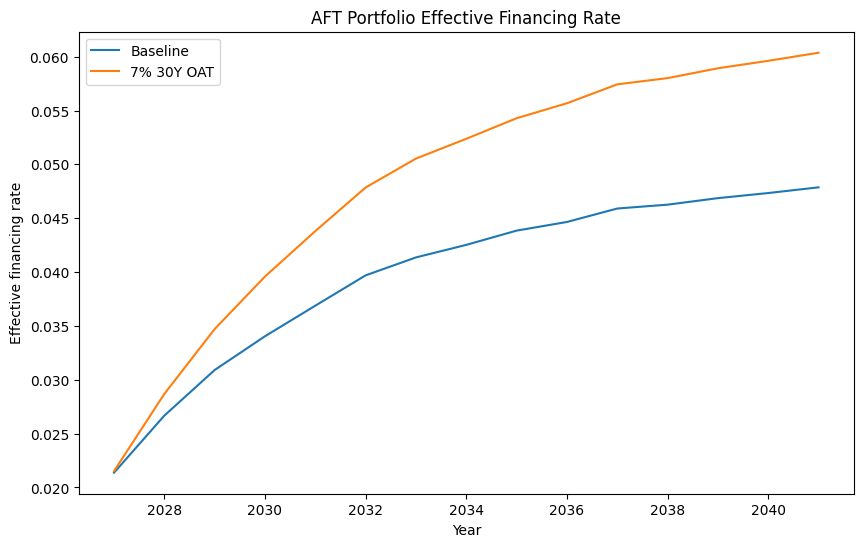

In [15]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    aft_baseline_path["year"],
    aft_baseline_path[
        "effective_financing_rate"
    ],
    label="Baseline"
)

ax.plot(
    aft_stress_path["year"],
    aft_stress_path[
        "effective_financing_rate"
    ],
    label="7% 30Y OAT"
)

ax.set_title(
    "AFT Portfolio Effective Financing Rate"
)

ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "Effective financing rate"
)

ax.legend()

plt.show()

In [16]:
# ============================================================
# AFT interest-cost shock
# ============================================================

aft_interest_cost_shock = (
    aft_comparison
    .set_index("year")[
        "interest_cost_shock_eur"
    ]
)

aft_interest_cost_shock

year
2027    4.257171e+08
2028    5.916857e+09
2029    1.197185e+10
2030    1.885073e+10
2031    2.563325e+10
2032    3.305207e+10
2033    4.081762e+10
2034    4.829491e+10
2035    5.647649e+10
2036    6.573872e+10
2037    7.596502e+10
2038    8.561947e+10
2039    9.698841e+10
2040    1.090182e+11
2041    1.224448e+11
Name: interest_cost_shock_eur, dtype: float64

In [17]:
def simulate_general_government_dsa(
    years,
    initial_gdp_eur,
    initial_debt_gdp,
    baseline_effective_rate,
    nominal_growth,
    primary_balance_gdp,
    interest_cost_shock=None,
):
    """
    Deterministic general-government debt sustainability model.

    Parameters
    ----------
    years
        Simulation years.

    initial_gdp_eur
        Nominal GDP immediately before the first simulation year.

    initial_debt_gdp
        General-government debt / GDP immediately before
        the first simulation year.

    baseline_effective_rate
        Effective interest rate on the inherited
        general-government debt stock.

    nominal_growth
        Annual nominal GDP growth rate.

    primary_balance_gdp
        Primary balance as a share of GDP.

        Positive = primary surplus.
        Negative = primary deficit.

    interest_cost_shock
        Additional annual interest/financing cost in euros.

        This is where the AFT stress transmission enters
        the general-government model.
    """

    years = list(years)

    # --------------------------------------------------------
    # Helper for scalar or year-specific assumptions
    # --------------------------------------------------------

    def get_year_value(value, year):

        if np.isscalar(value):
            return float(value)

        if isinstance(value, pd.Series):
            return float(
                value.loc[year]
            )

        if isinstance(value, dict):
            return float(
                value[year]
            )

        raise TypeError(
            "Assumption must be a scalar, dict, "
            "or pandas Series."
        )

    # --------------------------------------------------------
    # Initial state
    # --------------------------------------------------------

    gdp = float(
        initial_gdp_eur
    )

    debt = (
        gdp
        * float(
            initial_debt_gdp
        )
    )

    if interest_cost_shock is None:

        interest_cost_shock = pd.Series(
            0.0,
            index=years,
        )

    results = []

    # --------------------------------------------------------
    # Annual simulation
    # --------------------------------------------------------

    for year in years:

        growth = get_year_value(
            nominal_growth,
            year,
        )

        primary_balance_ratio = (
            get_year_value(
                primary_balance_gdp,
                year,
            )
        )

        effective_rate = get_year_value(
            baseline_effective_rate,
            year,
        )

        shock_eur = get_year_value(
            interest_cost_shock,
            year,
        )

        # Beginning-of-year state
        gdp_start = gdp
        debt_start = debt

        debt_gdp_start = (
            debt_start
            / gdp_start
        )

        # ----------------------------------------------------
        # GDP
        # ----------------------------------------------------

        gdp_end = (
            gdp_start
            * (1.0 + growth)
        )

        # ----------------------------------------------------
        # Baseline interest bill
        # ----------------------------------------------------

        baseline_interest_eur = (
            debt_start
            * effective_rate
        )

        # ----------------------------------------------------
        # Add incremental AFT market stress
        # ----------------------------------------------------

        total_interest_eur = (
            baseline_interest_eur
            + shock_eur
        )

        implied_effective_rate = (
            total_interest_eur
            / debt_start
        )

        # ----------------------------------------------------
        # Primary balance
        #
        # Positive = surplus -> reduces debt
        # Negative = deficit -> increases debt
        # ----------------------------------------------------

        primary_balance_eur = (
            primary_balance_ratio
            * gdp_end
        )

        # ----------------------------------------------------
        # Debt dynamics
        # ----------------------------------------------------

        debt_end = (
            debt_start
            + total_interest_eur
            - primary_balance_eur
        )

        debt_gdp_end = (
            debt_end
            / gdp_end
        )

        # ----------------------------------------------------
        # Store year
        # ----------------------------------------------------

        results.append({
            "year":
                year,

            "gdp_start_eur":
                gdp_start,

            "gdp_end_eur":
                gdp_end,

            "nominal_growth":
                growth,

            "debt_start_eur":
                debt_start,

            "debt_gdp_start":
                debt_gdp_start,

            "baseline_effective_rate":
                effective_rate,

            "baseline_interest_eur":
                baseline_interest_eur,

            "aft_interest_cost_shock_eur":
                shock_eur,

            "total_interest_eur":
                total_interest_eur,

            "implied_effective_rate":
                implied_effective_rate,

            "interest_gdp":
                total_interest_eur
                / gdp_end,

            "primary_balance_gdp":
                primary_balance_ratio,

            "primary_balance_eur":
                primary_balance_eur,

            "debt_end_eur":
                debt_end,

            "debt_gdp_end":
                debt_gdp_end,
        })

        # Roll forward
        gdp = gdp_end
        debt = debt_end

    return pd.DataFrame(
        results
    )

In [18]:
YEARS = (
    aft_baseline_path[
        "year"
    ]
    .astype(int)
    .tolist()
)


gg_baseline_path = (
    simulate_general_government_dsa(
        years=YEARS,

        initial_gdp_eur=(
            BASELINE[
                "initial_gdp_eur"
            ]
        ),

        initial_debt_gdp=(
            BASELINE[
                "initial_debt_gdp"
            ]
        ),

        baseline_effective_rate=(
            BASELINE[
                "effective_interest_rate"
            ]
        ),

        nominal_growth=(
            BASELINE[
                "nominal_growth"
            ]
        ),

        primary_balance_gdp=(
            BASELINE[
                "initial_primary_balance_gdp"
            ]
        ),

        interest_cost_shock=None,
    )
)

gg_baseline_path[
    [
        "year",
        "nominal_growth",
        "baseline_effective_rate",
        "interest_gdp",
        "primary_balance_gdp",
        "debt_gdp_end",
    ]
]

,year,nominal_growth,baseline_effective_rate,interest_gdp,primary_balance_gdp,debt_gdp_end
0,2027,0.028171,0.0229,0.026460,-0.026,1.207910
1,2028,0.028171,0.0229,0.026903,-0.026,1.227717
2,2029,0.028171,0.0229,0.027344,-0.026,1.247423
3,2030,0.028171,0.0229,0.027783,-0.026,1.267028
4,2031,0.028171,0.0229,0.028220,-0.026,1.286533
5,2032,0.028171,0.0229,0.028654,-0.026,1.305937
6,2033,0.028171,0.0229,0.029087,-0.026,1.325242
7,2034,0.028171,0.0229,0.029517,-0.026,1.344448
8,2035,0.028171,0.0229,0.029944,-0.026,1.363556
9,2036,0.028171,0.0229,0.030370,-0.026,1.382565


In [19]:
gg_stress_path = (
    simulate_general_government_dsa(
        years=YEARS,

        initial_gdp_eur=(
            BASELINE[
                "initial_gdp_eur"
            ]
        ),

        initial_debt_gdp=(
            BASELINE[
                "initial_debt_gdp"
            ]
        ),

        baseline_effective_rate=(
            BASELINE[
                "effective_interest_rate"
            ]
        ),

        nominal_growth=(
            BASELINE[
                "nominal_growth"
            ]
        ),

        primary_balance_gdp=(
            BASELINE[
                "initial_primary_balance_gdp"
            ]
        ),

        interest_cost_shock=(
            aft_interest_cost_shock
        ),
    )
)

In [20]:
gg_comparison = pd.DataFrame({
    "year":
        gg_baseline_path["year"],

    "baseline_debt_gdp":
        gg_baseline_path[
            "debt_gdp_end"
        ],

    "stress_debt_gdp":
        gg_stress_path[
            "debt_gdp_end"
        ],

    "baseline_interest_gdp":
        gg_baseline_path[
            "interest_gdp"
        ],

    "stress_interest_gdp":
        gg_stress_path[
            "interest_gdp"
        ],

    "baseline_effective_rate":
        gg_baseline_path[
            "implied_effective_rate"
        ],

    "stress_effective_rate":
        gg_stress_path[
            "implied_effective_rate"
        ],

    "aft_interest_cost_shock_eur":
        aft_interest_cost_shock.values,
})


gg_comparison[
    "debt_gdp_difference_pp"
] = (
    (
        gg_comparison[
            "stress_debt_gdp"
        ]
        -
        gg_comparison[
            "baseline_debt_gdp"
        ]
    )
    * 100
)


gg_comparison[
    "aft_interest_cost_shock_bn"
] = (
    gg_comparison[
        "aft_interest_cost_shock_eur"
    ]
    / 1e9
)


gg_comparison

,year,baseline_debt_gdp,stress_debt_gdp,baseline_interest_gdp,stress_interest_gdp,baseline_effective_rate,stress_effective_rate,aft_interest_cost_shock_eur,debt_gdp_difference_pp,aft_interest_cost_shock_bn
0,2027,1.207910,1.208045,0.026460,0.026595,0.0229,0.023017,4.257171e+08,0.013562,0.425717
1,2028,1.227717,1.229685,0.026903,0.028740,0.0229,0.024460,5.916857e+09,0.196821,5.916857
2,2029,1.247423,1.252989,0.027344,0.030996,0.0229,0.025917,1.197185e+10,0.556585,11.971846
3,2030,1.267028,1.278091,0.027783,0.033432,0.0229,0.027434,1.885073e+10,1.106236,18.850730
4,2031,1.286533,1.304845,0.028220,0.035773,0.0229,0.028778,2.563325e+10,1.831277,25.633253
5,2032,1.305937,1.333320,0.028654,0.038226,0.0229,0.030121,3.305207e+10,2.738268,33.052071
6,2033,1.325242,1.363491,0.029087,0.040703,0.0229,0.031388,4.081762e+10,3.824906,40.817622
7,2034,1.344448,1.395167,0.029517,0.043035,0.0229,0.032451,4.829491e+10,5.071921,48.294912
8,2035,1.363556,1.428421,0.029944,0.045480,0.0229,0.033517,5.647649e+10,6.486537,56.476494
9,2036,1.382565,1.463408,0.030370,0.048124,0.0229,0.034639,6.573872e+10,8.084219,65.738724


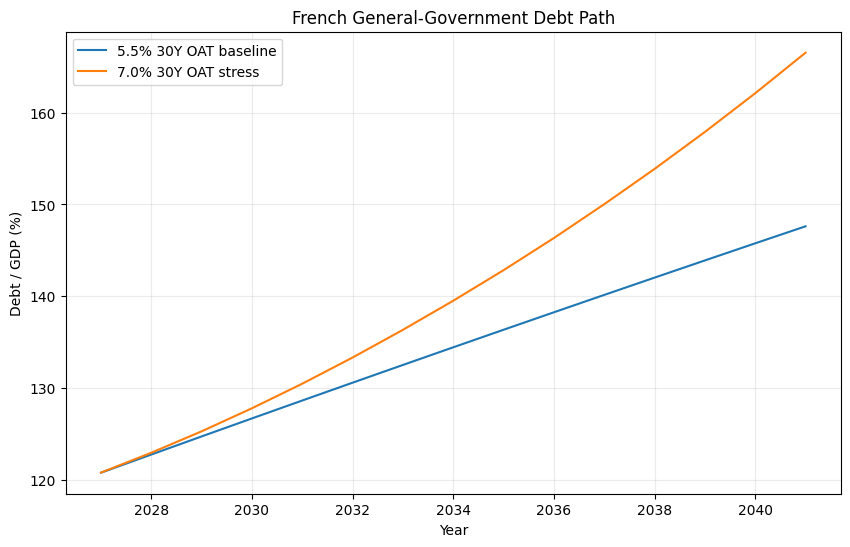

In [21]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    gg_comparison[
        "year"
    ],
    gg_comparison[
        "baseline_debt_gdp"
    ] * 100,
    label="5.5% 30Y OAT baseline",
)

ax.plot(
    gg_comparison[
        "year"
    ],
    gg_comparison[
        "stress_debt_gdp"
    ] * 100,
    label="7.0% 30Y OAT stress",
)

ax.set_title(
    "French General-Government Debt Path"
)

ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "Debt / GDP (%)"
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.show()

In [22]:
first_year = (
    gg_baseline_path.iloc[0]
)

expected_debt_ratio = (
    (
        1
        + BASELINE[
            "effective_interest_rate"
        ]
    )
    /
    (
        1
        + BASELINE[
            "nominal_growth"
        ]
    )
    *
    BASELINE[
        "initial_debt_gdp"
    ]
    -
    BASELINE[
        "initial_primary_balance_gdp"
    ]
)


actual_debt_ratio = (
    first_year[
        "debt_gdp_end"
    ]
)


print(
    f"Equation result: "
    f"{expected_debt_ratio:.6f}"
)

print(
    f"Simulation result: "
    f"{actual_debt_ratio:.6f}"
)


assert np.isclose(
    expected_debt_ratio,
    actual_debt_ratio,
    atol=1e-10,
)

print(
    "Debt-dynamics validation passed."
)

Equation result: 1.207910
Simulation result: 1.207910
Debt-dynamics validation passed.


In [23]:
# ============================================================
# Stochastic process configuration
# ============================================================

STOCHASTIC_VARIABLES = [
    "real_growth",
    "inflation",
    "primary_balance_gdp",
    "euro_30y",
    "france_spread_30y",
]


# ------------------------------------------------------------
# Starting conditions
# ------------------------------------------------------------

BASELINE_FRANCE_SPREAD_30Y = 0.017

BASELINE_EURO_30Y = (
    BASELINE_OAT_30Y
    - BASELINE_FRANCE_SPREAD_30Y
)


INITIAL_STATE = {
    "real_growth":
        BASELINE["real_growth"],

    "inflation":
        BASELINE["inflation"],

    "primary_balance_gdp":
        BASELINE["initial_primary_balance_gdp"],

    "euro_30y":
        BASELINE_EURO_30Y,

    "france_spread_30y":
        BASELINE_FRANCE_SPREAD_30Y,
}


# ------------------------------------------------------------
# Long-run means
# ------------------------------------------------------------

LONG_RUN_MEAN = {
    "real_growth": 0.010,
    "inflation": 0.020,
    "primary_balance_gdp": -0.015,
    "euro_30y": 0.035,
    "france_spread_30y": 0.015,
}


# ------------------------------------------------------------
# AR(1) persistence
#
# Higher rho = shocks take longer to disappear.
# ------------------------------------------------------------

PERSISTENCE = {
    "real_growth": 0.35,
    "inflation": 0.65,
    "primary_balance_gdp": 0.70,
    "euro_30y": 0.85,
    "france_spread_30y": 0.80,
}


# ------------------------------------------------------------
# Annual innovation volatility
# ------------------------------------------------------------

SHOCK_STD = {
    "real_growth": 0.015,
    "inflation": 0.010,
    "primary_balance_gdp": 0.012,
    "euro_30y": 0.006,
    "france_spread_30y": 0.0045,
}

In [24]:
# ============================================================
# Shock correlation matrix
# ============================================================

CORRELATION_MATRIX = np.array([
    # Growth  Inflation  Primary   Euro rate  FR spread
    [ 1.00,    0.15,      0.45,      0.25,     -0.35],  # Growth

    [ 0.15,    1.00,     -0.10,      0.45,      0.10],  # Inflation

    [ 0.45,   -0.10,      1.00,      0.00,     -0.45],  # Primary balance

    [ 0.25,    0.45,      0.00,      1.00,     -0.10],  # Euro long rate

    [-0.35,    0.10,     -0.45,     -0.10,      1.00],  # France spread
])


# ============================================================
# Correlation-matrix validation
# ============================================================

assert CORRELATION_MATRIX.shape == (
    len(STOCHASTIC_VARIABLES),
    len(STOCHASTIC_VARIABLES),
)

assert np.allclose(
    CORRELATION_MATRIX,
    CORRELATION_MATRIX.T,
)

assert np.allclose(
    np.diag(CORRELATION_MATRIX),
    1.0,
)


eigenvalues = np.linalg.eigvalsh(
    CORRELATION_MATRIX
)

print(
    "Correlation-matrix eigenvalues:"
)

print(
    eigenvalues
)


assert (
    eigenvalues > 0
).all(), (
    "Correlation matrix is not positive definite."
)

print(
    "Correlation matrix validation passed."
)

Correlation-matrix eigenvalues:
[0.46172621 0.51326282 0.64178197 1.49366646 1.88956254]
Correlation matrix validation passed.


In [25]:
# ============================================================
# Covariance matrix
# ============================================================

shock_std_vector = np.array([
    SHOCK_STD[var]
    for var in STOCHASTIC_VARIABLES
])


COVARIANCE_MATRIX = (
    np.outer(
        shock_std_vector,
        shock_std_vector,
    )
    *
    CORRELATION_MATRIX
)


COVARIANCE_MATRIX

array([[ 2.2500e-04,  2.2500e-05,  8.1000e-05,  2.2500e-05, -2.3625e-05],
       [ 2.2500e-05,  1.0000e-04, -1.2000e-05,  2.7000e-05,  4.5000e-06],
       [ 8.1000e-05, -1.2000e-05,  1.4400e-04,  0.0000e+00, -2.4300e-05],
       [ 2.2500e-05,  2.7000e-05,  0.0000e+00,  3.6000e-05, -2.7000e-06],
       [-2.3625e-05,  4.5000e-06, -2.4300e-05, -2.7000e-06,  2.0250e-05]])

In [26]:
def generate_stochastic_path(
    years,
    rng,
):
    """
    Generate one correlated stochastic macro-financial path.

    Each variable follows:

        x_t = mu + rho * (x_{t-1} - mu) + epsilon_t

    where the innovations epsilon_t are jointly correlated.
    """

    years = list(
        years
    )

    previous = {
        variable:
            float(
                INITIAL_STATE[
                    variable
                ]
            )
        for variable
        in STOCHASTIC_VARIABLES
    }

    rows = []

    for year in years:

        # ----------------------------------------------------
        # Draw correlated innovations
        # ----------------------------------------------------

        shocks = rng.multivariate_normal(
            mean=np.zeros(
                len(
                    STOCHASTIC_VARIABLES
                )
            ),
            cov=COVARIANCE_MATRIX,
        )

        current = {}

        # ----------------------------------------------------
        # AR(1) evolution
        # ----------------------------------------------------

        for i, variable in enumerate(
            STOCHASTIC_VARIABLES
        ):

            mu = LONG_RUN_MEAN[
                variable
            ]

            rho = PERSISTENCE[
                variable
            ]

            current[
                variable
            ] = (
                mu
                +
                rho
                * (
                    previous[
                        variable
                    ]
                    - mu
                )
                +
                shocks[i]
            )

        # ----------------------------------------------------
        # Economic bounds
        #
        # These prevent pathological Monte Carlo draws from
        # breaking the debt engine.
        # ----------------------------------------------------

        current[
            "real_growth"
        ] = np.clip(
            current[
                "real_growth"
            ],
            -0.08,
            0.06,
        )

        current[
            "inflation"
        ] = np.clip(
            current[
                "inflation"
            ],
            -0.02,
            0.08,
        )

        current[
            "primary_balance_gdp"
        ] = np.clip(
            current[
                "primary_balance_gdp"
            ],
            -0.10,
            0.05,
        )

        current[
            "euro_30y"
        ] = np.clip(
            current[
                "euro_30y"
            ],
            0.005,
            0.10,
        )

        current[
            "france_spread_30y"
        ] = np.clip(
            current[
                "france_spread_30y"
            ],
            0.001,
            0.08,
        )

        # ----------------------------------------------------
        # Derived quantities
        # ----------------------------------------------------

        nominal_growth = (
            (
                1
                + current[
                    "real_growth"
                ]
            )
            *
            (
                1
                + current[
                    "inflation"
                ]
            )
            - 1
        )

        oat_30y = (
            current[
                "euro_30y"
            ]
            +
            current[
                "france_spread_30y"
            ]
        )

        rows.append({
            "year":
                year,

            **current,

            "nominal_growth":
                nominal_growth,

            "oat_30y":
                oat_30y,
        })

        previous = current

    return pd.DataFrame(
        rows
    )

In [27]:
rng = np.random.default_rng(
    RANDOM_SEED
)

stochastic_path = (
    generate_stochastic_path(
        years=YEARS,
        rng=rng,
    )
)

stochastic_path

,year,real_growth,inflation,primary_balance_gdp,euro_30y,france_spread_30y,nominal_growth,oat_30y
0,2027,-0.000507,0.016381,-0.015604,0.028806,0.009837,0.015866,0.038643
1,2028,0.026256,0.019166,-0.007308,0.031035,0.005298,0.045926,0.036333
2,2029,0.005781,0.026574,-0.021320,0.027954,0.012899,0.032508,0.040853
3,2030,0.026012,0.024890,-0.019684,0.026075,0.013139,0.051550,0.039214
4,2031,0.011211,0.024023,-0.005862,0.027459,0.010216,0.035503,0.037675
5,2032,0.015701,0.029844,-0.006630,0.029641,0.012943,0.046014,0.042584
6,2033,-0.017689,0.016004,-0.027496,0.029707,0.018814,-0.001968,0.048521
7,2034,-0.012886,0.009087,-0.037076,0.031830,0.021964,-0.003917,0.053794
8,2035,-0.004175,0.013282,-0.043850,0.031090,0.023626,0.009051,0.054716
9,2036,0.003839,0.024726,-0.041207,0.031231,0.024252,0.028660,0.055483


In [28]:
stochastic_display = (
    stochastic_path.copy()
)


percentage_columns = [
    "real_growth",
    "inflation",
    "nominal_growth",
    "primary_balance_gdp",
    "euro_30y",
    "france_spread_30y",
    "oat_30y",
]


for col in percentage_columns:

    stochastic_display[
        col
    ] *= 100


stochastic_display.round(2)

,year,real_growth,inflation,primary_balance_gdp,euro_30y,france_spread_30y,nominal_growth,oat_30y
0,2027,-0.05,1.64,-1.56,2.88,0.98,1.59,3.86
1,2028,2.63,1.92,-0.73,3.10,0.53,4.59,3.63
2,2029,0.58,2.66,-2.13,2.80,1.29,3.25,4.09
3,2030,2.60,2.49,-1.97,2.61,1.31,5.15,3.92
4,2031,1.12,2.40,-0.59,2.75,1.02,3.55,3.77
5,2032,1.57,2.98,-0.66,2.96,1.29,4.60,4.26
6,2033,-1.77,1.60,-2.75,2.97,1.88,-0.20,4.85
7,2034,-1.29,0.91,-3.71,3.18,2.20,-0.39,5.38
8,2035,-0.42,1.33,-4.38,3.11,2.36,0.91,5.47
9,2036,0.38,2.47,-4.12,3.12,2.43,2.87,5.55


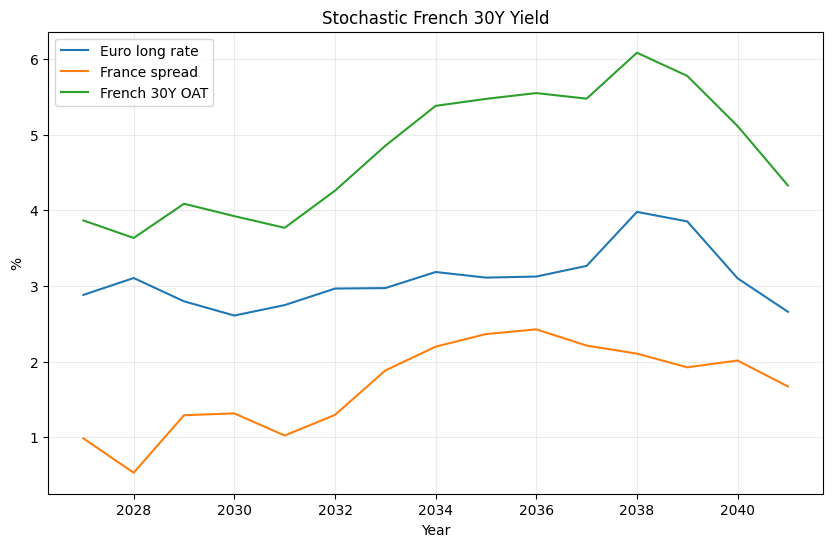

In [29]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    stochastic_path["year"],
    stochastic_path["euro_30y"] * 100,
    label="Euro long rate",
)

ax.plot(
    stochastic_path["year"],
    stochastic_path["france_spread_30y"] * 100,
    label="France spread",
)

ax.plot(
    stochastic_path["year"],
    stochastic_path["oat_30y"] * 100,
    label="French 30Y OAT",
)

ax.set_title(
    "Stochastic French 30Y Yield"
)

ax.set_ylabel(
    "%"
)

ax.set_xlabel(
    "Year"
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.show()

In [30]:
def build_stochastic_market_curves(
    stochastic_path,
):
    """
    Convert the stochastic 30Y OAT path into yearly
    nominal and real yield curves.
    """

    curve_path = {}

    for _, row in (
        stochastic_path.iterrows()
    ):

        year = int(
            row["year"]
        )

        oat_30y = float(
            row["oat_30y"]
        )

        # ----------------------------------------------------
        # Nominal curve
        # ----------------------------------------------------

        nominal_curve = (
            curve_from_30y_anchor(
                oat_30y_yield=oat_30y,
                offsets_to_30y=(
                    NOMINAL_CURVE_OFFSETS_TO_30Y
                ),
            )
        )

        # ----------------------------------------------------
        # Real linker curves
        #
        # First-pass assumption:
        # shift real curves by the same change in the French
        # long rate relative to baseline.
        # ----------------------------------------------------

        yield_shift = (
            oat_30y
            - BASELINE_OAT_30Y
        )

        real_euro_curve = {
            maturity:
                rate
                + yield_shift

            for maturity, rate
            in baseline_real_euro_curve.items()
        }

        real_fr_curve = {
            maturity:
                rate
                + yield_shift

            for maturity, rate
            in baseline_real_fr_curve.items()
        }

        curve_path[
            year
        ] = {
            "nominal":
                nominal_curve,

            "real_euro":
                real_euro_curve,

            "real_fr":
                real_fr_curve,
        }

    return curve_path

In [31]:
stochastic_market_curves = (
    build_stochastic_market_curves(
        stochastic_path
    )
)

In [32]:
stochastic_indexed = (
    stochastic_path
    .set_index("year")
)


stochastic_nominal_growth = (
    stochastic_indexed[
        "nominal_growth"
    ]
)


stochastic_primary_balance = (
    stochastic_indexed[
        "primary_balance_gdp"
    ]
)


stochastic_inflation = (
    stochastic_indexed[
        "inflation"
    ]
)

In [33]:
aft_stochastic_path, aft_stochastic_final = (
    simulate_portfolio_path(
        initial_portfolio=portfolio,

        initial_gdp_eur=(
            BASELINE[
                "initial_gdp_eur"
            ]
        ),

        start_year=(
            BASELINE[
                "start_year"
            ]
        ),

        years=(
            BASELINE[
                "horizon_years"
            ]
        ),

        nominal_growth=(
            stochastic_nominal_growth
            .to_dict()
        ),

        primary_balance_ratio=(
            stochastic_primary_balance
            .to_dict()
        ),

        market_curves=(
            stochastic_market_curves
        ),

        issuance_plan=(
            ISSUANCE_PLAN
        ),

        french_inflation=(
            stochastic_inflation
            .to_dict()
        ),

        euro_inflation=(
            stochastic_inflation
            .to_dict()
        ),
    )
)


aft_stochastic_path[
    [
        "year",
        "weighted_market_issue_rate",
        "effective_financing_rate",
        "indexation_accrual_eur",
        "total_financing_cost_eur",
    ]
]

,year,weighted_market_issue_rate,effective_financing_rate,indexation_accrual_eur,total_financing_cost_eur
0,2027,0.029828,0.020680,5.201614e+09,6.055420e+10
1,2028,0.027518,0.023929,6.221138e+09,6.930523e+10
2,2029,0.032038,0.026700,9.004276e+09,7.978681e+10
3,2030,0.030399,0.027841,8.464139e+09,8.734354e+10
4,2031,0.028860,0.029030,8.644783e+09,9.552378e+10
5,2032,0.033769,0.031035,1.141534e+10,1.057258e+11
6,2033,0.039706,0.030500,6.249370e+09,1.078661e+11
7,2034,0.044979,0.031251,3.954003e+09,1.171709e+11
8,2035,0.045901,0.034122,6.217665e+09,1.367502e+11
9,2036,0.046668,0.037292,1.298621e+10,1.607552e+11


In [34]:
stochastic_aft_cost_shock = pd.Series(
    (
        aft_stochastic_path[
            "total_financing_cost_eur"
        ].values
        -
        aft_baseline_path[
            "total_financing_cost_eur"
        ].values
    ),
    index=YEARS,
)

In [35]:
gg_stochastic_path = (
    simulate_general_government_dsa(
        years=YEARS,

        initial_gdp_eur=(
            BASELINE[
                "initial_gdp_eur"
            ]
        ),

        initial_debt_gdp=(
            BASELINE[
                "initial_debt_gdp"
            ]
        ),

        baseline_effective_rate=(
            BASELINE[
                "effective_interest_rate"
            ]
        ),

        nominal_growth=(
            stochastic_nominal_growth
        ),

        primary_balance_gdp=(
            stochastic_primary_balance
        ),

        interest_cost_shock=(
            stochastic_aft_cost_shock
        ),
    )
)

In [36]:
stochastic_results = pd.DataFrame({
    "year":
        stochastic_path["year"],

    "real_growth":
        stochastic_path[
            "real_growth"
        ],

    "inflation":
        stochastic_path[
            "inflation"
        ],

    "nominal_growth":
        stochastic_path[
            "nominal_growth"
        ],

    "primary_balance_gdp":
        stochastic_path[
            "primary_balance_gdp"
        ],

    "oat_30y":
        stochastic_path[
            "oat_30y"
        ],

    "france_spread_30y":
        stochastic_path[
            "france_spread_30y"
        ],

    "aft_effective_rate":
        aft_stochastic_path[
            "effective_financing_rate"
        ],

    "gg_effective_rate":
        gg_stochastic_path[
            "implied_effective_rate"
        ],

    "interest_gdp":
        gg_stochastic_path[
            "interest_gdp"
        ],

    "debt_gdp":
        gg_stochastic_path[
            "debt_gdp_end"
        ],
})


stochastic_results

,year,real_growth,inflation,nominal_growth,primary_balance_gdp,oat_30y,france_spread_30y,aft_effective_rate,gg_effective_rate,interest_gdp,debt_gdp
0,2027,-0.000507,0.016381,0.015866,-0.015604,0.038643,0.009837,0.020680,0.022342,0.026127,1.211176
1,2028,0.026256,0.019166,0.045926,-0.007308,0.036333,0.005298,0.023929,0.020545,0.023791,1.189094
2,2029,0.005781,0.026574,0.032508,-0.021320,0.040853,0.012899,0.026700,0.018827,0.021682,1.194658
3,2030,0.026012,0.024890,0.051550,-0.019684,0.039214,0.013139,0.027841,0.016915,0.019217,1.174994
4,2031,0.011211,0.024023,0.035503,-0.005862,0.037675,0.010216,0.029030,0.015087,0.017120,1.157690
5,2032,0.015701,0.029844,0.046014,-0.006630,0.042584,0.012943,0.031035,0.013311,0.014732,1.128125
6,2033,-0.017689,0.016004,-0.001968,-0.027496,0.048521,0.018814,0.030500,0.010282,0.011623,1.169469
7,2034,-0.012886,0.009087,-0.003917,-0.037076,0.053794,0.021964,0.031251,0.009323,0.010946,1.222090
8,2035,-0.004175,0.013282,0.009051,-0.043850,0.054716,0.023626,0.034122,0.010296,0.012470,1.267447
9,2036,0.003839,0.024726,0.028660,-0.041207,0.055483,0.024252,0.037292,0.012359,0.015228,1.288569


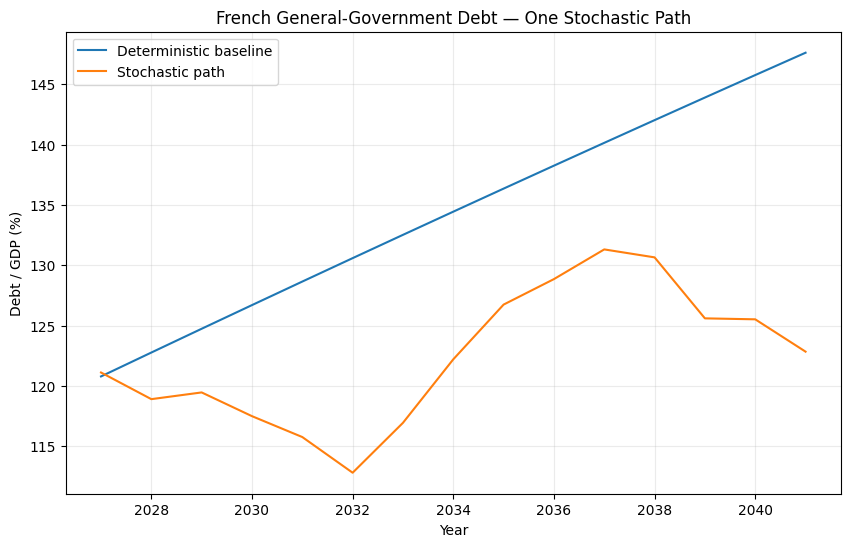

In [37]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    gg_baseline_path[
        "year"
    ],
    gg_baseline_path[
        "debt_gdp_end"
    ] * 100,
    label="Deterministic baseline",
)

ax.plot(
    gg_stochastic_path[
        "year"
    ],
    gg_stochastic_path[
        "debt_gdp_end"
    ] * 100,
    label="Stochastic path",
)

ax.set_title(
    "French General-Government Debt — One Stochastic Path"
)

ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "Debt / GDP (%)"
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.show()

In [38]:
from pathlib import Path
from io import StringIO

import pandas as pd
import requests

from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry


# ============================================================
# ECB API session
# ============================================================

def create_ecb_session():

    retry_strategy = Retry(
        total=6,
        connect=6,
        read=6,
        status=6,

        backoff_factor=1.5,

        status_forcelist=[
            429,
            500,
            502,
            503,
            504,
        ],

        allowed_methods=frozenset([
            "GET",
        ]),

        respect_retry_after_header=True,
    )

    adapter = HTTPAdapter(
        max_retries=retry_strategy
    )

    session = requests.Session()

    session.mount(
        "https://",
        adapter,
    )

    session.mount(
        "http://",
        adapter,
    )

    session.headers.update({
        "Accept": "text/csv",

        # Requests will decompress automatically.
        "Accept-Encoding":
            "gzip, deflate",

        "User-Agent":
            "french-oat-model/1.0",
    })

    return session


ECB_SESSION = create_ecb_session()

# ============================================================
# ECB data downloader
# ============================================================

def fetch_ecb_series(
    series_key,
    start_period="1999-01",
    end_period="2025-12",
    cache_dir=None,
    force_refresh=False,
):
    """
    Download one ECB IRS series.

    Features:
    - automatic retry;
    - long read timeout;
    - reduced API payload;
    - optional local CSV cache.
    """

    # --------------------------------------------------------
    # Cache path
    # --------------------------------------------------------

    cache_path = None

    if cache_dir is not None:

        cache_dir = Path(
            cache_dir
        )

        cache_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        safe_key = (
            series_key
            .replace(".", "_")
            .replace("+", "_")
        )

        cache_path = (
            cache_dir
            / (
                f"ecb_IRS_{safe_key}_"
                f"{start_period}_{end_period}.csv"
            )
        )

        if (
            cache_path.exists()
            and not force_refresh
        ):

            print(
                f"Loading cached ECB data:\n"
                f"{cache_path}"
            )

            df = pd.read_csv(
                cache_path,
                parse_dates=[
                    "TIME_PERIOD"
                ],
            )

            return df

    # --------------------------------------------------------
    # API request
    # --------------------------------------------------------

    url = (
        "https://data-api.ecb.europa.eu/"
        f"service/data/IRS/{series_key}"
    )

    params = {
        "startPeriod":
            start_period,

        "endPeriod":
            end_period,

        "format":
            "csvdata",

        # Exclude unnecessary attributes / metadata.
        "detail":
            "dataonly",
    }

    print(
        f"Downloading ECB series:\n"
        f"{series_key}"
    )

    try:

        response = ECB_SESSION.get(
            url,
            params=params,

            # 10 sec connection timeout,
            # 180 sec read timeout.
            timeout=(
                10,
                180,
            ),
        )

        response.raise_for_status()

    except requests.exceptions.RequestException as exc:

        # If the API happens to fail but we have an
        # older cached copy, keep the notebook usable.
        if (
            cache_path is not None
            and cache_path.exists()
        ):

            print(
                "\nECB request failed. "
                "Using cached copy instead."
            )

            return pd.read_csv(
                cache_path,
                parse_dates=[
                    "TIME_PERIOD"
                ],
            )

        raise RuntimeError(
            "ECB API request failed and no "
            "cached copy is available."
        ) from exc

    # --------------------------------------------------------
    # Parse response
    # --------------------------------------------------------

    if not response.text.strip():

        raise ValueError(
            "ECB API returned an empty response."
        )

    df = pd.read_csv(
        StringIO(
            response.text
        )
    )

    required_columns = {
        "TIME_PERIOD",
        "OBS_VALUE",
    }

    missing = (
        required_columns
        - set(df.columns)
    )

    if missing:

        raise ValueError(
            "Unexpected ECB response. "
            f"Missing columns: {missing}\n\n"
            f"Returned columns:\n"
            f"{df.columns.tolist()}"
        )

    df["TIME_PERIOD"] = pd.to_datetime(
        df["TIME_PERIOD"],
        errors="coerce",
    )

    df["OBS_VALUE"] = pd.to_numeric(
        df["OBS_VALUE"],
        errors="coerce",
    )

    df = (
        df[
            [
                "TIME_PERIOD",
                "OBS_VALUE",
            ]
        ]
        .dropna()
        .sort_values(
            "TIME_PERIOD"
        )
        .reset_index(
            drop=True
        )
    )

    # --------------------------------------------------------
    # Save locally
    # --------------------------------------------------------

    if cache_path is not None:

        df.to_csv(
            cache_path,
            index=False,
        )

        print(
            f"Cached to:\n"
            f"{cache_path}"
        )

    print(
        f"Observations downloaded: "
        f"{len(df):,}"
    )

    return df

ECB_CACHE_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "ecb"
)

FRANCE_10Y_KEY = (
    "M.FR.L.L40.CI.0000.EUR.N.Z"
)

GERMANY_10Y_KEY = (
    "M.DE.L.L40.CI.0000.EUR.N.Z"
)


france_10y_monthly = (
    fetch_ecb_series(
        series_key=FRANCE_10Y_KEY,
        start_period="1999-01",
        end_period="2025-12",
        cache_dir=ECB_CACHE_DIR,
    )
)


germany_10y_monthly = (
    fetch_ecb_series(
        series_key=GERMANY_10Y_KEY,
        start_period="1999-01",
        end_period="2025-12",
        cache_dir=ECB_CACHE_DIR,
    )
)

M.FR.L.L40.CI.0000.EUR.N.Z
Cached to:
c:\Users\mikel\Desktop\french_oat_model\data\raw\ecb\ecb_IRS_M_FR_L_L40_CI_0000_EUR_N_Z_1999-01_2025-12.csv
Observations downloaded: 324
M.DE.L.L40.CI.0000.EUR.N.Z
Cached to:
c:\Users\mikel\Desktop\french_oat_model\data\raw\ecb\ecb_IRS_M_DE_L_L40_CI_0000_EUR_N_Z_1999-01_2025-12.csv
Observations downloaded: 324


In [39]:
# ============================================================
# Eurostat API
# ============================================================

EUROSTAT_CACHE_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "eurostat"
)


def _jsonstat_category_labels(
    category_index
):
    """
    Return JSON-stat category labels in positional order.
    """

    if isinstance(
        category_index,
        dict,
    ):
        return [
            label
            for label, _
            in sorted(
                category_index.items(),
                key=lambda x: x[1],
            )
        ]

    return list(
        category_index
    )


def fetch_eurostat_series(
    dataset_code,
    filters,
    value_name,
    cache_dir=EUROSTAT_CACHE_DIR,
    force_refresh=False,
):
    """
    Download a Eurostat series using the Statistics API.

    This function assumes the query restricts every dimension
    except time to exactly one category.
    """

    cache_dir = Path(
        cache_dir
    )

    cache_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    filter_string = "_".join(
        f"{key}-{value}"
        for key, value
        in sorted(
            filters.items()
        )
    )

    cache_path = (
        cache_dir
        / (
            f"{dataset_code}_"
            f"{filter_string}.csv"
        )
    )

    # --------------------------------------------------------
    # Cache
    # --------------------------------------------------------

    if (
        cache_path.exists()
        and not force_refresh
    ):

        print(
            f"Loading cached Eurostat data:\n"
            f"{cache_path}"
        )

        return pd.read_csv(
            cache_path
        )

    # --------------------------------------------------------
    # Request
    # --------------------------------------------------------

    url = (
        "https://ec.europa.eu/"
        "eurostat/api/dissemination/"
        "statistics/1.0/data/"
        f"{dataset_code}"
    )

    params = {
        "lang": "EN",
        **filters,
    }

    print(
        f"Downloading Eurostat dataset: "
        f"{dataset_code}"
    )

    response = requests.get(
        url,
        params=params,
        timeout=(
            10,
            180,
        ),
    )

    response.raise_for_status()

    data = response.json()

    # --------------------------------------------------------
    # Validate JSON-stat structure
    # --------------------------------------------------------

    dimension_ids = data[
        "id"
    ]

    dimension_sizes = data[
        "size"
    ]

    if "time" not in dimension_ids:
        raise ValueError(
            "Eurostat response contains no "
            "'time' dimension."
        )

    time_pos = (
        dimension_ids.index(
            "time"
        )
    )

    for i, dimension in enumerate(
        dimension_ids
    ):

        if (
            dimension != "time"
            and dimension_sizes[i] != 1
        ):

            raise ValueError(
                "Eurostat query did not reduce "
                f"dimension {dimension!r} "
                "to one category."
            )

    time_index = (
        data[
            "dimension"
        ][
            "time"
        ][
            "category"
        ][
            "index"
        ]
    )

    years = (
        _jsonstat_category_labels(
            time_index
        )
    )

    values = data[
        "value"
    ]

    rows = []

    # --------------------------------------------------------
    # Convert flattened JSON-stat cube
    # --------------------------------------------------------

    for time_coordinate, year in enumerate(
        years
    ):

        coordinates = [
            0
            for _ in dimension_ids
        ]

        coordinates[
            time_pos
        ] = time_coordinate

        flat_index = int(
            np.ravel_multi_index(
                tuple(
                    coordinates
                ),
                tuple(
                    dimension_sizes
                ),
                order="C",
            )
        )

        if isinstance(
            values,
            dict,
        ):
            value = values.get(
                str(flat_index),
                np.nan,
            )

        else:
            value = (
                values[flat_index]
                if flat_index < len(values)
                else np.nan
            )

        rows.append({
            "year":
                int(year),

            value_name:
                value,
        })

    result = pd.DataFrame(
        rows
    )

    result[
        value_name
    ] = pd.to_numeric(
        result[
            value_name
        ],
        errors="coerce",
    )

    result.to_csv(
        cache_path,
        index=False,
    )

    print(
        f"Observations downloaded: "
        f"{result[value_name].notna().sum()}"
    )

    return result

In [40]:
real_growth_history = (
    fetch_eurostat_series(
        dataset_code="nama_10_gdp",

        filters={
            "freq": "A",
            "unit": "CLV_PCH_PRE",
            "na_item": "B1GQ",
            "geo": "FR",
        },

        value_name="real_growth",
    )
)

Observations downloaded: 51


In [41]:
real_growth_history[
    "real_growth"
] = (
    real_growth_history[
        "real_growth"
    ]
    / 100
)

In [42]:
real_growth_history = (
    real_growth_history[
        real_growth_history["year"]
        .between(
            1999,
            2025,
        )
    ]
    .reset_index(
        drop=True
    )
)

real_growth_history

,year,real_growth
0,1999,0.034
1,2000,0.041
2,2001,0.019
3,2002,0.011
4,2003,0.010
5,2004,0.029
6,2005,0.019
7,2006,0.027
8,2007,0.025
9,2008,0.004


In [43]:
inflation_history = (
    fetch_eurostat_series(
        dataset_code="prc_hicp_aind",

        filters={
            "freq": "A",
            "unit": "RCH_A_AVG",
            "coicop": "CP00",
            "geo": "FR",
        },

        value_name="inflation",
    )
)

Observations downloaded: 30


In [44]:
inflation_history[
    "inflation"
] = (
    inflation_history[
        "inflation"
    ]
    / 100
)


inflation_history = (
    inflation_history[
        inflation_history["year"]
        .between(
            1999,
            2025,
        )
    ]
    .reset_index(
        drop=True
    )
)

In [49]:
# ============================================================
# Convert ECB monthly yields to annual averages
# ============================================================

def monthly_rate_to_annual(
    df,
    column_name,
):
    """
    Convert ECB monthly yield observations from percentage
    points to decimal rates and calculate annual averages.

    Example:
        3.50 from ECB -> 0.035
    """

    result = df.copy()

    result["TIME_PERIOD"] = pd.to_datetime(
        result["TIME_PERIOD"]
    )

    result["year"] = (
        result["TIME_PERIOD"]
        .dt.year
    )

    result[column_name] = (
        pd.to_numeric(
            result["OBS_VALUE"],
            errors="coerce",
        )
        / 100
    )

    result = (
        result[
            [
                "year",
                column_name,
            ]
        ]
        .dropna()
        .groupby(
            "year",
            as_index=False,
        )[column_name]
        .mean()
    )

    return result


# ============================================================
# France 10Y annual average
# ============================================================

france_10y_annual = (
    monthly_rate_to_annual(
        france_10y_monthly,
        "france_10y",
    )
)


# ============================================================
# Germany 10Y annual average
# ============================================================

germany_10y_annual = (
    monthly_rate_to_annual(
        germany_10y_monthly,
        "bund_10y",
    )
)


# ============================================================
# Merge and calculate France-Germany sovereign spread
# ============================================================

rates_history = (
    france_10y_annual
    .merge(
        germany_10y_annual,
        on="year",
        how="inner",
        validate="one_to_one",
    )
)


rates_history[
    "france_spread_10y"
] = (
    rates_history[
        "france_10y"
    ]
    -
    rates_history[
        "bund_10y"
    ]
)


# ============================================================
# Restrict to calibration sample
# ============================================================

rates_history = (
    rates_history[
        rates_history["year"]
        .between(
            1999,
            2025,
        )
    ]
    .sort_values(
        "year"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# Validation
# ============================================================

assert (
    rates_history["year"]
    .is_unique
)

assert not (
    rates_history[
        [
            "france_10y",
            "bund_10y",
            "france_spread_10y",
        ]
    ]
    .isna()
    .any()
    .any()
)


print(
    f"Rate-history sample: "
    f"{rates_history['year'].min()}"
    f"–"
    f"{rates_history['year'].max()}"
)

print(
    f"Observations: "
    f"{len(rates_history)}"
)


rates_history

Rate-history sample: 1999–2025
Observations: 27


,year,france_10y,bund_10y,france_spread_10y
0,1999,0.046192,0.044908,0.001283
1,2000,0.053942,0.052633,0.001308
2,2001,0.049392,0.047975,0.001417
3,2002,0.048600,0.047825,0.000775
4,2003,0.041300,0.040708,0.000592
5,2004,0.040983,0.040367,0.000617
6,2005,0.034100,0.033533,0.000567
7,2006,0.037967,0.037625,0.000342
8,2007,0.043042,0.042167,0.000875
9,2008,0.042342,0.039842,0.002500


In [50]:
# ============================================================
# AMECO primary balance via DBnomics
# ============================================================

DBNOMICS_CACHE_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "ameco"
)


def fetch_ameco_primary_balance(
    cache_dir=DBNOMICS_CACHE_DIR,
    force_refresh=False,
):

    cache_dir = Path(
        cache_dir
    )

    cache_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    cache_path = (
        cache_dir
        / "france_primary_balance_gdp.csv"
    )

    if (
        cache_path.exists()
        and not force_refresh
    ):

        print(
            f"Loading cached AMECO data:\n"
            f"{cache_path}"
        )

        return pd.read_csv(
            cache_path
        )

    # France
    # annual
    # % GDP
    # primary balance
    series_code = (
        "FRA.1.0.319.0.UBLGI"
    )

    url = (
        "https://api.db.nomics.world/"
        "v22/series/"
        f"AMECO/UBLGI/{series_code}"
    )

    params = {
        "observations": 1,
    }

    print(
        "Downloading AMECO "
        "primary-balance series..."
    )

    response = requests.get(
        url,
        params=params,
        timeout=(
            10,
            180,
        ),
    )

    response.raise_for_status()

    payload = response.json()

    docs = (
        payload
        .get(
            "series",
            {}
        )
        .get(
            "docs",
            []
        )
    )

    if not docs:
        raise ValueError(
            "DBnomics returned no AMECO "
            "series observations."
        )

    series = docs[0]

    periods = series[
        "period"
    ]

    values = series[
        "value"
    ]

    result = pd.DataFrame({
        "year":
            pd.to_numeric(
                periods,
                errors="coerce",
            ),

        "primary_balance_gdp":
            pd.to_numeric(
                values,
                errors="coerce",
            ),
    })

    result = (
        result
        .dropna()
        .copy()
    )

    result["year"] = (
        result["year"]
        .astype(int)
    )

    # DBnomics/AMECO gives percentage points.
    result[
        "primary_balance_gdp"
    ] /= 100

    result = (
        result[
            result["year"]
            .between(
                1999,
                2025,
            )
        ]
        .reset_index(
            drop=True
        )
    )

    result.to_csv(
        cache_path,
        index=False,
    )

    return result

In [51]:
primary_balance_history = (
    fetch_ameco_primary_balance()
)

Loading cached AMECO data:
c:\Users\mikel\Desktop\french_oat_model\data\raw\ameco\france_primary_balance_gdp.csv


In [52]:
macro_history = (
    real_growth_history
    .merge(
        inflation_history,
        on="year",
        how="inner",
    )
    .merge(
        primary_balance_history,
        on="year",
        how="inner",
    )
)


calibration_data = (
    macro_history
    .merge(
        rates_history[
            [
                "year",
                "bund_10y",
                "france_spread_10y",
            ]
        ],
        on="year",
        how="inner",
    )
)

In [53]:
CALIBRATION_START_YEAR = 1999
CALIBRATION_END_YEAR = 2025


calibration_data = (
    calibration_data[
        calibration_data["year"]
        .between(
            CALIBRATION_START_YEAR,
            CALIBRATION_END_YEAR,
        )
    ]
    .sort_values(
        "year"
    )
    .reset_index(
        drop=True
    )
)

In [54]:
# ============================================================
# Historical calibration-data validation
# ============================================================

CALIBRATION_VARIABLES = [
    "real_growth",
    "inflation",
    "primary_balance_gdp",
    "bund_10y",
    "france_spread_10y",
]


expected_years = set(
    range(
        CALIBRATION_START_YEAR,
        CALIBRATION_END_YEAR + 1,
    )
)

actual_years = set(
    calibration_data["year"]
)


missing_years = (
    expected_years
    - actual_years
)


assert not missing_years, (
    f"Missing calibration years: "
    f"{sorted(missing_years)}"
)


assert (
    calibration_data["year"]
    .is_unique
), (
    "Duplicate calibration years found."
)


assert not (
    calibration_data[
        CALIBRATION_VARIABLES
    ]
    .isna()
    .any()
    .any()
), (
    "NULL values remain in "
    "calibration dataset."
)


assert len(
    calibration_data
) == 27


print(
    "Historical calibration "
    "dataset validation passed."
)

print(
    f"Sample: "
    f"{calibration_data['year'].min()}"
    f"–"
    f"{calibration_data['year'].max()}"
)

print(
    f"Observations: "
    f"{len(calibration_data)}"
)

Historical calibration dataset validation passed.
Sample: 1999–2025
Observations: 27


In [55]:
calibration_summary = (
    calibration_data[
        CALIBRATION_VARIABLES
    ]
    .describe()
    .T
)


calibration_summary

,count,mean,std,min,25%,50%,75%,max
real_growth,27.0,0.014556,0.024026,-0.074000,0.009500,0.016000,0.024500,0.069000
inflation,27.0,0.018333,0.013859,0.001000,0.009500,0.018000,0.022000,0.059000
primary_balance_gdp,27.0,-0.018921,0.021713,-0.076505,-0.028460,-0.018613,-0.005896,0.016466
bund_10y,27.0,0.023789,0.017979,-0.005107,0.008191,0.026083,0.040104,0.052633
france_spread_10y,27.0,0.003695,0.002575,0.000342,0.001296,0.003767,0.005309,0.010417


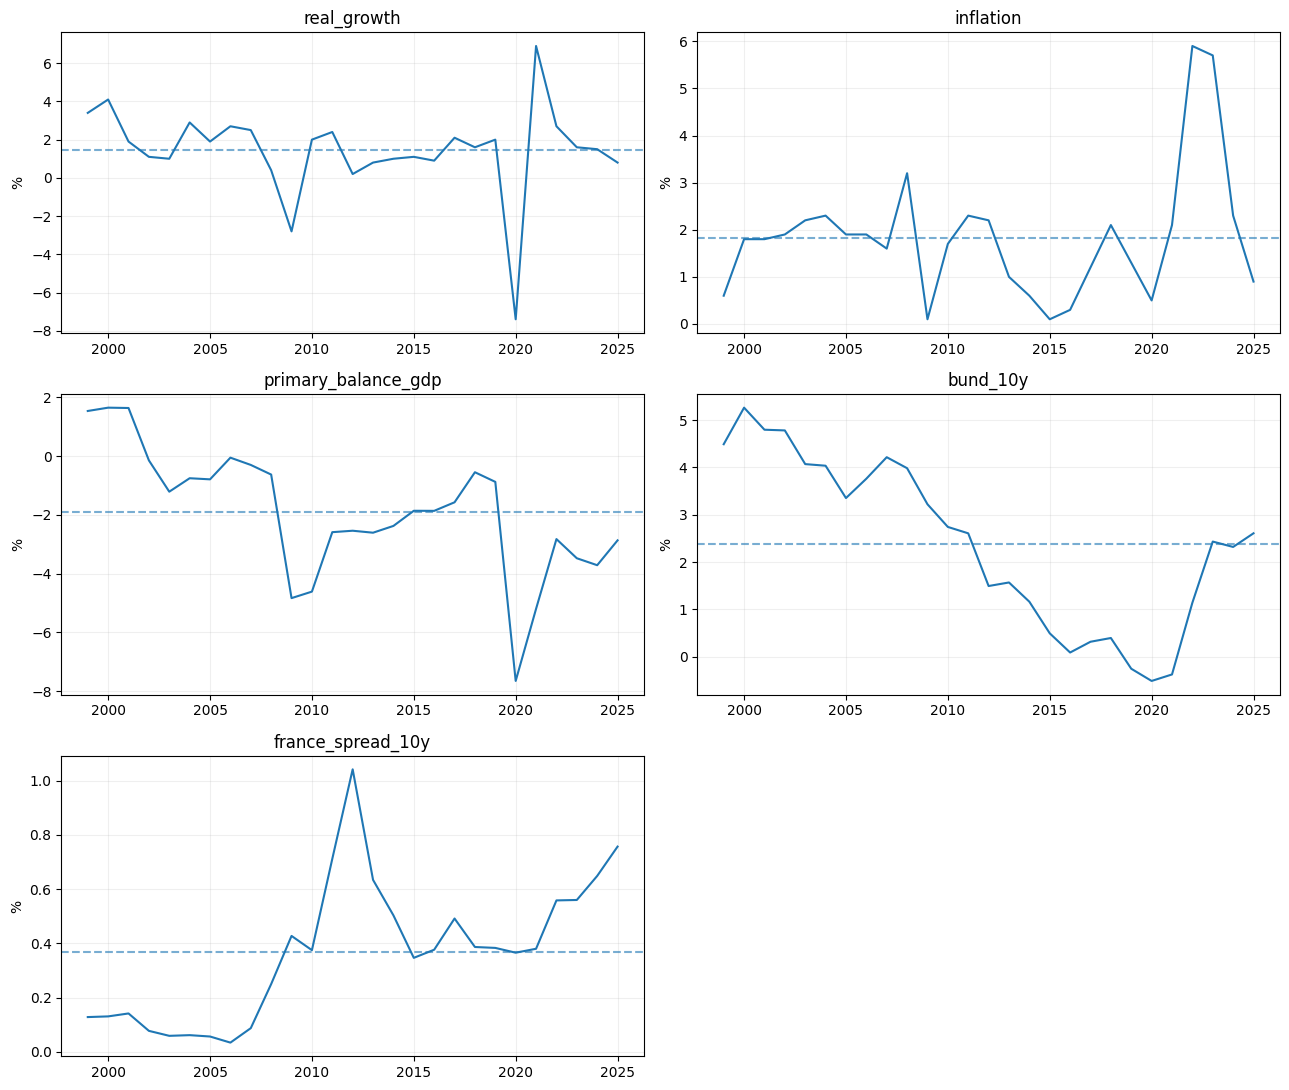

In [56]:
fig, axes = plt.subplots(
    3,
    2,
    figsize=(13, 11)
)

axes = axes.flatten()


for ax, variable in zip(
    axes,
    CALIBRATION_VARIABLES,
):

    ax.plot(
        calibration_data[
            "year"
        ],
        calibration_data[
            variable
        ] * 100,
    )

    ax.axhline(
        calibration_data[
            variable
        ].mean() * 100,
        linestyle="--",
        alpha=0.6,
    )

    ax.set_title(
        variable
    )

    ax.set_ylabel(
        "%"
    )

    ax.grid(
        alpha=0.2
    )


axes[-1].axis(
    "off"
)

plt.tight_layout()
plt.show()

In [58]:
# ============================================================
# AR(1) estimation helper
# ============================================================

def estimate_ar1(
    series,
    variable_name,
):
    """
    Estimate the AR(1) process:

        x_t = c + rho * x_(t-1) + epsilon_t

    and derive:

        long_run_mean = c / (1 - rho)

    Parameters
    ----------
    series
        Historical time series.

    variable_name
        Name used for diagnostics.

    Returns
    -------
    dict
        Estimated intercept, persistence, long-run mean,
        innovation standard deviation, fitted values,
        and residuals.
    """

    # --------------------------------------------------------
    # Clean input
    # --------------------------------------------------------

    x = (
        pd.Series(series)
        .dropna()
        .astype(float)
        .to_numpy()
    )

    if len(x) < 10:
        raise ValueError(
            f"Too few observations for "
            f"{variable_name}: {len(x)}"
        )

    if not np.isfinite(x).all():
        raise ValueError(
            f"{variable_name} contains "
            "non-finite observations."
        )

    if np.isclose(
        np.std(x),
        0.0,
    ):
        raise ValueError(
            f"{variable_name} is effectively constant."
        )

    # --------------------------------------------------------
    # Construct lagged regression
    #
    # y_t = c + rho * y_(t-1) + epsilon_t
    # --------------------------------------------------------

    y = x[1:]

    x_lag = x[:-1]

    X = np.column_stack([
        np.ones(
            len(x_lag)
        ),
        x_lag,
    ])

    # --------------------------------------------------------
    # OLS estimation
    # --------------------------------------------------------

    beta = np.linalg.lstsq(
        X,
        y,
        rcond=None,
    )[0]

    intercept = float(
        beta[0]
    )

    rho = float(
        beta[1]
    )

    # --------------------------------------------------------
    # Fitted values and residuals
    # --------------------------------------------------------

    fitted = (
        intercept
        + rho * x_lag
    )

    residuals = (
        y
        - fitted
    )

    # Two estimated coefficients:
    # intercept and rho
    degrees_of_freedom = (
        len(residuals)
        - 2
    )

    if degrees_of_freedom <= 0:
        raise ValueError(
            f"Insufficient degrees of freedom "
            f"for {variable_name}."
        )

    innovation_std = float(
        np.sqrt(
            np.sum(
                residuals ** 2
            )
            / degrees_of_freedom
        )
    )

    # --------------------------------------------------------
    # Long-run mean
    # --------------------------------------------------------

    if abs(rho) < 1.0:

        long_run_mean = (
            intercept
            / (
                1.0
                - rho
            )
        )

    else:

        long_run_mean = np.nan

    # --------------------------------------------------------
    # Return diagnostics
    # --------------------------------------------------------

    return {
        "variable":
            variable_name,

        "n_observations":
            len(x),

        "intercept":
            intercept,

        "rho":
            rho,

        "long_run_mean":
            long_run_mean,

        "innovation_std":
            innovation_std,

        "fitted":
            fitted,

        "residuals":
            residuals,
    }

In [59]:
ar1_results = {}


for variable in (
    CALIBRATION_VARIABLES
):

    ar1_results[
        variable
    ] = estimate_ar1(
        calibration_data[
            variable
        ],
        variable,
    )

In [60]:
ar1_summary = pd.DataFrame([
    {
        "variable":
            variable,

        "long_run_mean":
            result[
                "long_run_mean"
            ],

        "rho":
            result[
                "rho"
            ],

        "innovation_std":
            result[
                "innovation_std"
            ],
    }

    for variable, result
    in ar1_results.items()
])


ar1_summary[
    "long_run_mean_pct"
] = (
    ar1_summary[
        "long_run_mean"
    ]
    * 100
)


ar1_summary[
    "innovation_std_pct"
] = (
    ar1_summary[
        "innovation_std"
    ]
    * 100
)


ar1_summary[
    [
        "variable",
        "long_run_mean_pct",
        "rho",
        "innovation_std_pct",
    ]
].round(3)

,variable,long_run_mean_pct,rho,innovation_std_pct
0,real_growth,1.400,-0.242,2.393
1,inflation,1.891,0.460,1.258
2,primary_balance_gdp,-2.276,0.598,1.670
3,bund_10y,1.510,0.916,0.611
4,france_spread_10y,0.518,0.852,0.148


In [61]:
PERSISTENCE = {
    variable:
        ar1_results[
            variable
        ]["rho"]

    for variable
    in CALIBRATION_VARIABLES
}


SHOCK_STD = {
    variable:
        ar1_results[
            variable
        ]["innovation_std"]

    for variable
    in CALIBRATION_VARIABLES
}

In [62]:
# ============================================================
# AR(1) innovation residuals
# ============================================================

residual_data = pd.DataFrame({
    variable:
        ar1_results[
            variable
        ]["residuals"]

    for variable
    in CALIBRATION_VARIABLES
})

In [63]:
raw_residual_correlation = (
    residual_data.corr()
)


raw_residual_correlation.round(3)

,real_growth,inflation,primary_balance_gdp,bund_10y,france_spread_10y
real_growth,1.000,0.518,0.905,0.457,-0.005
inflation,0.518,1.000,0.406,0.604,0.200
primary_balance_gdp,0.905,0.406,1.000,0.297,-0.031
bund_10y,0.457,0.604,0.297,1.000,-0.035
france_spread_10y,-0.005,0.200,-0.031,-0.035,1.000


In [65]:
from sklearn.covariance import LedoitWolf

In [66]:
# ============================================================
# Standardize AR(1) innovations
# ============================================================

standardized_residuals = (
    residual_data
    - residual_data.mean()
) / residual_data.std(
    ddof=1
)


# ============================================================
# Ledoit-Wolf shrinkage covariance
# ============================================================

lw = LedoitWolf().fit(
    standardized_residuals.values
)


shrunk_covariance = (
    lw.covariance_
)


# Convert covariance -> correlation
std = np.sqrt(
    np.diag(
        shrunk_covariance
    )
)


CORRELATION_MATRIX = (
    shrunk_covariance
    /
    np.outer(
        std,
        std,
    )
)


correlation_df = pd.DataFrame(
    CORRELATION_MATRIX,
    index=CALIBRATION_VARIABLES,
    columns=CALIBRATION_VARIABLES,
)


correlation_df.round(3)

,real_growth,inflation,primary_balance_gdp,bund_10y,france_spread_10y
real_growth,1.000,0.206,0.360,0.182,-0.002
inflation,0.206,1.000,0.162,0.241,0.080
primary_balance_gdp,0.360,0.162,1.000,0.118,-0.012
bund_10y,0.182,0.241,0.118,1.000,-0.014
france_spread_10y,-0.002,0.080,-0.012,-0.014,1.000


In [67]:
eigenvalues = (
    np.linalg.eigvalsh(
        CORRELATION_MATRIX
    )
)


print(
    "Eigenvalues:"
)

print(
    eigenvalues
)


print(
    "\nLedoit-Wolf shrinkage:"
)

print(
    lw.shrinkage_
)


assert (
    eigenvalues > 0
).all()


print(
    "\nCorrelation matrix validation passed."
)

Eigenvalues:
[0.63285326 0.73788979 0.95158484 1.03525647 1.64241563]

Ledoit-Wolf shrinkage:
0.6019302168077348

Correlation matrix validation passed.


In [69]:
raw_residual_correlation.round(3)

,real_growth,inflation,primary_balance_gdp,bund_10y,france_spread_10y
real_growth,1.000,0.518,0.905,0.457,-0.005
inflation,0.518,1.000,0.406,0.604,0.200
primary_balance_gdp,0.905,0.406,1.000,0.297,-0.031
bund_10y,0.457,0.604,0.297,1.000,-0.035
france_spread_10y,-0.005,0.200,-0.031,-0.035,1.000


In [70]:
correlation_df.round(3)

,real_growth,inflation,primary_balance_gdp,bund_10y,france_spread_10y
real_growth,1.000,0.206,0.360,0.182,-0.002
inflation,0.206,1.000,0.162,0.241,0.080
primary_balance_gdp,0.360,0.162,1.000,0.118,-0.012
bund_10y,0.182,0.241,0.118,1.000,-0.014
france_spread_10y,-0.002,0.080,-0.012,-0.014,1.000


In [71]:
# ============================================================
# Calibrated stochastic parameters
# ============================================================

PERSISTENCE = {
    variable:
        ar1_results[
            variable
        ]["rho"]

    for variable
    in CALIBRATION_VARIABLES
}


SHOCK_STD = {
    variable:
        ar1_results[
            variable
        ]["innovation_std"]

    for variable
    in CALIBRATION_VARIABLES
}


# Already estimated with Ledoit-Wolf
CALIBRATED_CORRELATION_MATRIX = (
    CORRELATION_MATRIX.copy()
)


print("Persistence:")
for variable, value in PERSISTENCE.items():
    print(
        f"{variable:25s}: "
        f"{value:.3f}"
    )


print("\nInnovation volatility:")
for variable, value in SHOCK_STD.items():
    print(
        f"{variable:25s}: "
        f"{value:.3%}"
    )

Persistence:
real_growth              : -0.242
inflation                : 0.460
primary_balance_gdp      : 0.598
bund_10y                 : 0.916
france_spread_10y        : 0.852

Innovation volatility:
real_growth              : 2.393%
inflation                : 1.258%
primary_balance_gdp      : 1.670%
bund_10y                 : 0.611%
france_spread_10y        : 0.148%


In [72]:
shock_std_vector = np.array([
    SHOCK_STD[
        variable
    ]

    for variable
    in CALIBRATION_VARIABLES
])


CALIBRATED_COVARIANCE_MATRIX = (
    np.outer(
        shock_std_vector,
        shock_std_vector,
    )
    *
    CALIBRATED_CORRELATION_MATRIX
)

In [73]:
eigenvalues = np.linalg.eigvalsh(
    CALIBRATED_COVARIANCE_MATRIX
)


assert (
    eigenvalues > 0
).all()


print(
    "Calibrated covariance matrix "
    "is positive definite."
)

Calibrated covariance matrix is positive definite.


In [74]:
# ============================================================
# Latest market state
# ============================================================

france_10y_current = fetch_ecb_series(
    series_key=FRANCE_10Y_KEY,
    start_period="2026-01",
    end_period="2026-10",
    cache_dir=ECB_CACHE_DIR,
)


germany_10y_current = fetch_ecb_series(
    series_key=GERMANY_10Y_KEY,
    start_period="2026-01",
    end_period="2026-10",
    cache_dir=ECB_CACHE_DIR,
)


latest_france_row = (
    france_10y_current
    .sort_values("TIME_PERIOD")
    .iloc[-1]
)

latest_germany_row = (
    germany_10y_current
    .sort_values("TIME_PERIOD")
    .iloc[-1]
)


CURRENT_FRANCE_10Y = (
    latest_france_row["OBS_VALUE"]
    / 100
)

CURRENT_BUND_10Y = (
    latest_germany_row["OBS_VALUE"]
    / 100
)

CURRENT_FRANCE_SPREAD_10Y = (
    CURRENT_FRANCE_10Y
    - CURRENT_BUND_10Y
)


print(
    "Latest France observation:",
    latest_france_row["TIME_PERIOD"]
)

print(
    f"France 10Y: "
    f"{CURRENT_FRANCE_10Y:.2%}"
)

print(
    f"Bund 10Y: "
    f"{CURRENT_BUND_10Y:.2%}"
)

print(
    f"France spread: "
    f"{CURRENT_FRANCE_SPREAD_10Y:.2%}"
)

M.FR.L.L40.CI.0000.EUR.N.Z
Cached to:
c:\Users\mikel\Desktop\french_oat_model\data\raw\ecb\ecb_IRS_M_FR_L_L40_CI_0000_EUR_N_Z_2026-01_2026-10.csv
Observations downloaded: 8
M.DE.L.L40.CI.0000.EUR.N.Z
Cached to:
c:\Users\mikel\Desktop\french_oat_model\data\raw\ecb\ecb_IRS_M_DE_L_L40_CI_0000_EUR_N_Z_2026-01_2026-10.csv
Observations downloaded: 8
Latest France observation: 2026-08-01 00:00:00
France 10Y: 4.00%
Bund 10Y: 3.19%
France spread: 0.81%


In [75]:
# ============================================================
# AR(1) expected path
# ============================================================

def build_ar1_expected_path(
    initial_value,
    long_run_mean,
    rho,
    years,
):
    """
    Generate the conditional expected path of an AR(1):

        x_t = mu + rho * (x_(t-1) - mu)

    No random innovations are added.
    """

    previous = float(
        initial_value
    )

    result = {}

    for year in years:

        current = (
            long_run_mean
            +
            rho
            * (
                previous
                - long_run_mean
            )
        )

        result[year] = current

        previous = current

    return result

In [76]:
# ============================================================
# Simulation years
# ============================================================

CENTRAL_START_YEAR = 2026
CENTRAL_END_YEAR = 2041

CENTRAL_YEARS = list(
    range(
        CENTRAL_START_YEAR,
        CENTRAL_END_YEAR + 1,
    )
)

SIMULATION_YEARS = list(
    range(
        2027,
        CENTRAL_END_YEAR + 1,
    )
)

In [77]:
# ============================================================
# Bund central path
# ============================================================

bund_expected = (
    build_ar1_expected_path(
        initial_value=(
            CURRENT_BUND_10Y
        ),

        long_run_mean=(
            ar1_results[
                "bund_10y"
            ][
                "long_run_mean"
            ]
        ),

        rho=(
            ar1_results[
                "bund_10y"
            ]["rho"]
        ),

        years=SIMULATION_YEARS,
    )
)


# ============================================================
# France spread central path
# ============================================================

spread_expected = (
    build_ar1_expected_path(
        initial_value=(
            CURRENT_FRANCE_SPREAD_10Y
        ),

        long_run_mean=(
            ar1_results[
                "france_spread_10y"
            ][
                "long_run_mean"
            ]
        ),

        rho=(
            ar1_results[
                "france_spread_10y"
            ]["rho"]
        ),

        years=SIMULATION_YEARS,
    )
)

In [78]:
# ============================================================
# Official / published central assumptions
# ============================================================

REAL_GROWTH_CENTRAL = {
    2026: 0.004,
    2027: 0.009,
    2028: 0.012,
    2029: 0.011,
    2030: 0.011,
    2031: 0.011,
}


INFLATION_CENTRAL = {
    2026: 0.023,
    2027: 0.019,
    2028: 0.016,
}


PRIMARY_BALANCE_CENTRAL = {
    2026: -0.027,
    2027: -0.023,
    2028: -0.017,
    2029: -0.011,
    2030: -0.006,
    2031: 0.000,
}

In [79]:
# ============================================================
# Inflation convergence to ECB target
# ============================================================

ECB_INFLATION_TARGET = 0.020


inflation_transition_years = [
    2029,
    2030,
    2031,
]


inflation_transition = np.linspace(
    INFLATION_CENTRAL[2028],
    ECB_INFLATION_TARGET,
    len(inflation_transition_years) + 1,
)[1:]


for year, value in zip(
    inflation_transition_years,
    inflation_transition,
):

    INFLATION_CENTRAL[
        year
    ] = float(value)

In [80]:
# ============================================================
# Extend terminal central assumptions
# ============================================================

for year in range(
    2032,
    CENTRAL_END_YEAR + 1,
):

    REAL_GROWTH_CENTRAL[
        year
    ] = (
        REAL_GROWTH_CENTRAL[
            2031
        ]
    )

    INFLATION_CENTRAL[
        year
    ] = (
        ECB_INFLATION_TARGET
    )

    PRIMARY_BALANCE_CENTRAL[
        year
    ] = (
        PRIMARY_BALANCE_CENTRAL[
            2031
        ]
    )

In [81]:
# ============================================================
# Central scenario
# ============================================================

central_path = pd.DataFrame({
    "year":
        CENTRAL_YEARS,
})


central_path[
    "real_growth"
] = central_path[
    "year"
].map(
    REAL_GROWTH_CENTRAL
)


central_path[
    "inflation"
] = central_path[
    "year"
].map(
    INFLATION_CENTRAL
)


central_path[
    "primary_balance_gdp"
] = central_path[
    "year"
].map(
    PRIMARY_BALANCE_CENTRAL
)

In [82]:
bund_central = {
    2026:
        CURRENT_BUND_10Y,

    **bund_expected,
}


spread_central = {
    2026:
        CURRENT_FRANCE_SPREAD_10Y,

    **spread_expected,
}


central_path[
    "bund_10y"
] = (
    central_path["year"]
    .map(
        bund_central
    )
)


central_path[
    "france_spread_10y"
] = (
    central_path["year"]
    .map(
        spread_central
    )
)

In [83]:
central_path[
    "france_10y"
] = (
    central_path[
        "bund_10y"
    ]
    +
    central_path[
        "france_spread_10y"
    ]
)

In [84]:
INITIAL_10S30S_SLOPE = (
    BASELINE_OAT_30Y
    - CURRENT_FRANCE_10Y
)


print(
    f"Initial France 10s30s slope: "
    f"{INITIAL_10S30S_SLOPE:.2%}"
)

Initial France 10s30s slope: 1.50%


In [85]:
central_path[
    "oat_30y"
] = (
    central_path[
        "france_10y"
    ]
    +
    INITIAL_10S30S_SLOPE
)

In [86]:
central_path[
    "nominal_growth"
] = (
    (
        1
        + central_path[
            "real_growth"
        ]
    )
    *
    (
        1
        + central_path[
            "inflation"
        ]
    )
    - 1
)

In [87]:
# ============================================================
# Central-path validation
# ============================================================

required_central_columns = [
    "real_growth",
    "inflation",
    "primary_balance_gdp",
    "bund_10y",
    "france_spread_10y",
    "france_10y",
    "oat_30y",
    "nominal_growth",
]


assert not (
    central_path[
        required_central_columns
    ]
    .isna()
    .any()
    .any()
), (
    "NULL value found in central path."
)


assert (
    central_path["year"]
    .is_unique
)


assert len(
    central_path
) == (
    CENTRAL_END_YEAR
    - CENTRAL_START_YEAR
    + 1
)


assert np.allclose(
    central_path[
        "france_10y"
    ],
    central_path[
        "bund_10y"
    ]
    +
    central_path[
        "france_spread_10y"
    ],
)


print(
    "Central path validation passed."
)

Central path validation passed.


In [88]:
central_display = (
    central_path.copy()
)


display_columns = [
    "real_growth",
    "inflation",
    "primary_balance_gdp",
    "bund_10y",
    "france_spread_10y",
    "france_10y",
    "oat_30y",
    "nominal_growth",
]


for column in display_columns:

    central_display[
        column
    ] *= 100


central_display.round(2)

,year,real_growth,inflation,primary_balance_gdp,bund_10y,france_spread_10y,france_10y,oat_30y,nominal_growth
0,2026,0.4,2.30,-2.7,3.19,0.81,4.00,5.50,2.71
1,2027,0.9,1.90,-2.3,3.04,0.77,3.81,5.31,2.82
2,2028,1.2,1.60,-1.7,2.91,0.73,3.65,5.15,2.82
3,2029,1.1,1.73,-1.1,2.80,0.70,3.50,5.00,2.85
4,2030,1.1,1.87,-0.6,2.69,0.67,3.36,4.86,2.99
5,2031,1.1,2.00,0.0,2.59,0.65,3.24,4.74,3.12
6,2032,1.1,2.00,0.0,2.50,0.63,3.13,4.63,3.12
7,2033,1.1,2.00,0.0,2.42,0.61,3.03,4.53,3.12
8,2034,1.1,2.00,0.0,2.34,0.60,2.94,4.44,3.12
9,2035,1.1,2.00,0.0,2.27,0.59,2.86,4.36,3.12


In [89]:
# ============================================================
# Calibrated stochastic path generator
# ============================================================

def generate_calibrated_stochastic_path(
    central_path,
    rng,
):
    """
    Generate one stochastic path around a time-varying
    central scenario.

    Dynamics:

        x_t =
            mu_t
            + rho * (x_(t-1) - mu_(t-1))
            + epsilon_t

    Innovations are correlated using the calibrated
    covariance matrix.
    """

    central = (
        central_path
        .set_index("year")
        .copy()
    )

    years = [
        year
        for year in central.index
        if year >= 2027
    ]

    # Start exactly at the 2026 central state.
    previous = {
        variable:
            float(
                central.loc[
                    2026,
                    variable,
                ]
            )

        for variable
        in CALIBRATION_VARIABLES
    }

    rows = []

    for year in years:

        previous_year = (
            year - 1
        )

        # ----------------------------------------------------
        # Correlated innovations
        # ----------------------------------------------------

        shocks = rng.multivariate_normal(
            mean=np.zeros(
                len(
                    CALIBRATION_VARIABLES
                )
            ),

            cov=(
                CALIBRATED_COVARIANCE_MATRIX
            ),
        )

        current = {}

        # ----------------------------------------------------
        # Evolution around central path
        # ----------------------------------------------------

        for i, variable in enumerate(
            CALIBRATION_VARIABLES
        ):

            mu_t = float(
                central.loc[
                    year,
                    variable,
                ]
            )

            mu_previous = float(
                central.loc[
                    previous_year,
                    variable,
                ]
            )

            rho = PERSISTENCE[
                variable
            ]

            current[
                variable
            ] = (
                mu_t
                +
                rho
                * (
                    previous[
                        variable
                    ]
                    - mu_previous
                )
                +
                shocks[i]
            )

        # ----------------------------------------------------
        # Derived market variables
        # ----------------------------------------------------

        france_10y = (
            current[
                "bund_10y"
            ]
            +
            current[
                "france_spread_10y"
            ]
        )

        oat_30y = (
            france_10y
            +
            INITIAL_10S30S_SLOPE
        )

        nominal_growth = (
            (
                1
                + current[
                    "real_growth"
                ]
            )
            *
            (
                1
                + current[
                    "inflation"
                ]
            )
            - 1
        )

        rows.append({
            "year":
                year,

            **current,

            "france_10y":
                france_10y,

            "oat_30y":
                oat_30y,

            "nominal_growth":
                nominal_growth,
        })

        previous = current

    return pd.DataFrame(
        rows
    )

In [90]:
rng = np.random.default_rng(
    RANDOM_SEED
)


stochastic_path = (
    generate_calibrated_stochastic_path(
        central_path=central_path,
        rng=rng,
    )
)

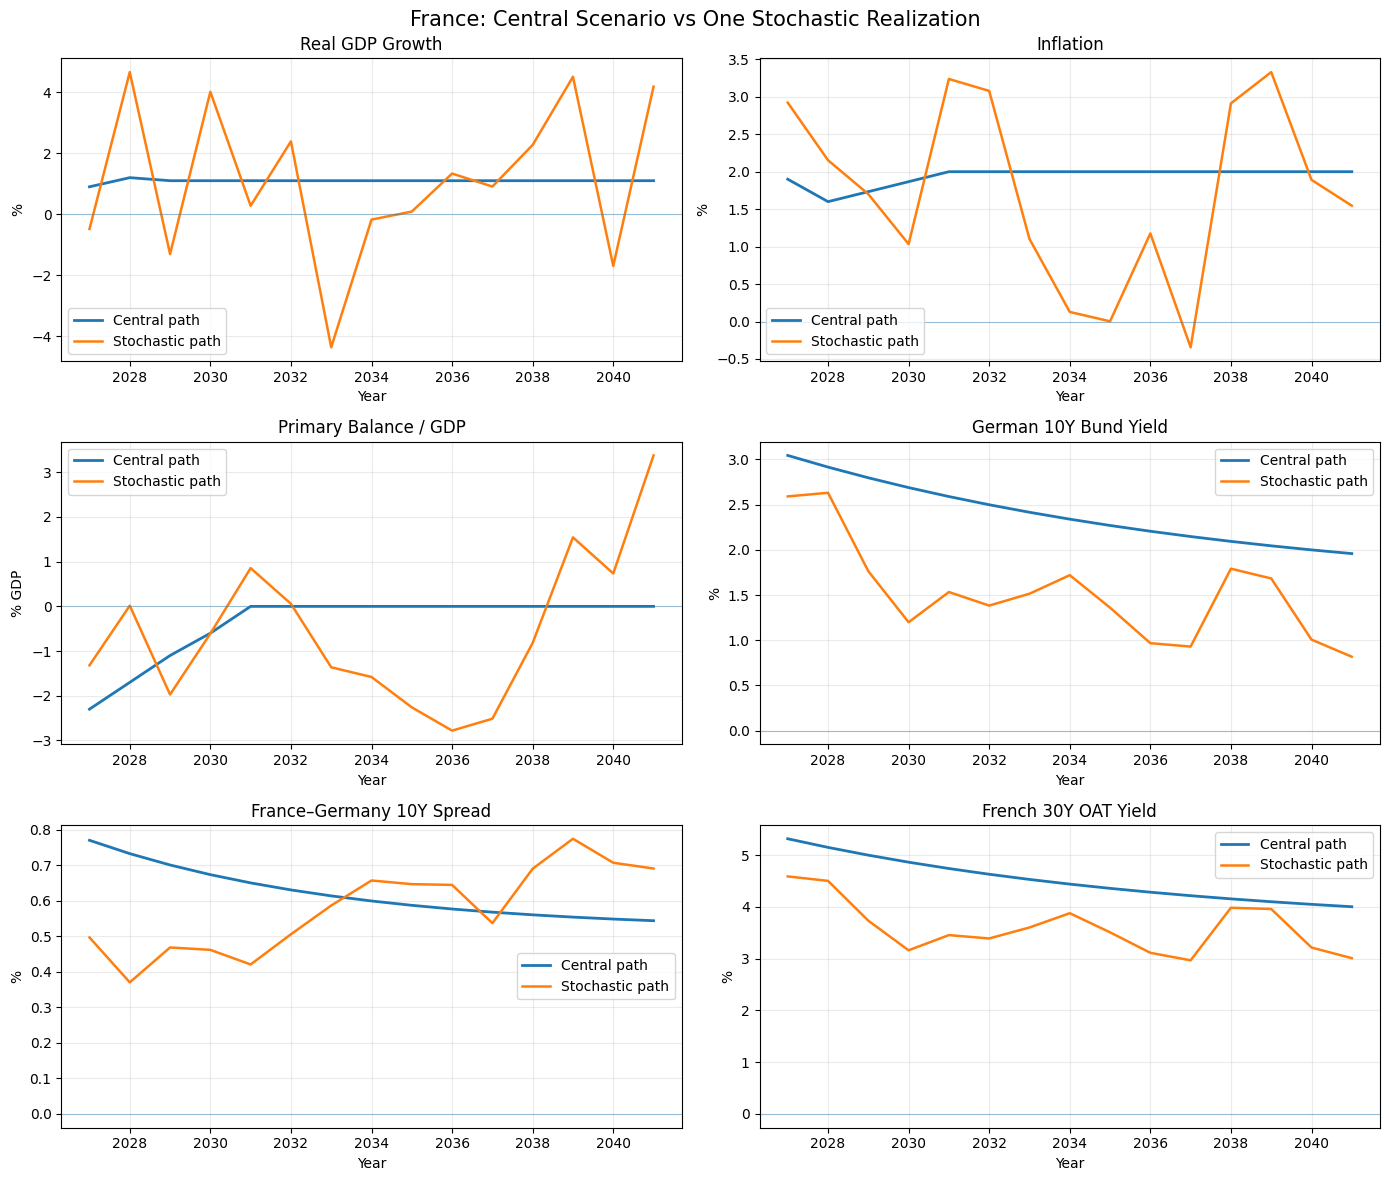

In [91]:
# ============================================================
# Central vs stochastic paths
# ============================================================

# Stochastic simulation begins in 2027, while central_path
# also contains 2026 as the initial state.
central_plot = (
    central_path[
        central_path["year"] >= 2027
    ]
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# Plot configuration
# ============================================================

plot_specs = [
    {
        "column": "real_growth",
        "title": "Real GDP Growth",
        "ylabel": "%",
    },
    {
        "column": "inflation",
        "title": "Inflation",
        "ylabel": "%",
    },
    {
        "column": "primary_balance_gdp",
        "title": "Primary Balance / GDP",
        "ylabel": "% GDP",
    },
    {
        "column": "bund_10y",
        "title": "German 10Y Bund Yield",
        "ylabel": "%",
    },
    {
        "column": "france_spread_10y",
        "title": "France–Germany 10Y Spread",
        "ylabel": "%",
    },
    {
        "column": "oat_30y",
        "title": "French 30Y OAT Yield",
        "ylabel": "%",
    },
]


# ============================================================
# Create plots
# ============================================================

fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 12),
)

axes = axes.flatten()


for ax, spec in zip(
    axes,
    plot_specs,
):

    column = spec[
        "column"
    ]

    # Central path
    ax.plot(
        central_plot[
            "year"
        ],
        central_plot[
            column
        ] * 100,
        label="Central path",
        linewidth=2,
    )

    # One stochastic realization
    ax.plot(
        stochastic_path[
            "year"
        ],
        stochastic_path[
            column
        ] * 100,
        label="Stochastic path",
        linewidth=1.8,
    )

    ax.axhline(
        0,
        linewidth=0.8,
        alpha=0.4,
    )

    ax.set_title(
        spec[
            "title"
        ]
    )

    ax.set_xlabel(
        "Year"
    )

    ax.set_ylabel(
        spec[
            "ylabel"
        ]
    )

    ax.grid(
        alpha=0.25
    )

    ax.legend()


fig.suptitle(
    "France: Central Scenario vs One Stochastic Realization",
    fontsize=15,
)

plt.tight_layout()

plt.show()

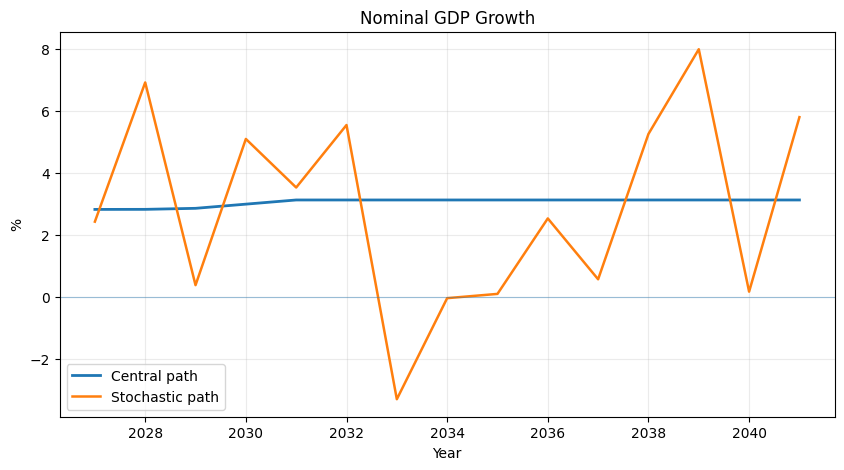

In [92]:
# ============================================================
# Nominal GDP growth
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 5)
)


ax.plot(
    central_plot[
        "year"
    ],
    central_plot[
        "nominal_growth"
    ] * 100,
    label="Central path",
    linewidth=2,
)


ax.plot(
    stochastic_path[
        "year"
    ],
    stochastic_path[
        "nominal_growth"
    ] * 100,
    label="Stochastic path",
    linewidth=1.8,
)


ax.axhline(
    0,
    linewidth=0.8,
    alpha=0.4,
)


ax.set_title(
    "Nominal GDP Growth"
)

ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "%"
)

ax.grid(
    alpha=0.25
)

ax.legend()

plt.show()

In [93]:
# ============================================================
# Deviations from central path
# ============================================================

path_comparison = (
    stochastic_path
    .merge(
        central_plot,
        on="year",
        suffixes=(
            "_stochastic",
            "_central",
        ),
        validate="one_to_one",
    )
)


for variable in [
    "real_growth",
    "inflation",
    "primary_balance_gdp",
    "bund_10y",
    "france_spread_10y",
    "oat_30y",
    "nominal_growth",
]:

    path_comparison[
        f"{variable}_deviation"
    ] = (
        path_comparison[
            f"{variable}_stochastic"
        ]
        -
        path_comparison[
            f"{variable}_central"
        ]
    )

In [94]:
deviation_columns = [
    "year",
    "real_growth_deviation",
    "inflation_deviation",
    "primary_balance_gdp_deviation",
    "bund_10y_deviation",
    "france_spread_10y_deviation",
    "oat_30y_deviation",
]


deviation_display = (
    path_comparison[
        deviation_columns
    ]
    .copy()
)


for column in deviation_columns[1:]:

    deviation_display[
        column
    ] *= 100


deviation_display.round(2)

,year,real_growth_deviation,inflation_deviation,primary_balance_gdp_deviation,bund_10y_deviation,france_spread_10y_deviation,oat_30y_deviation
0,2027,-1.39,1.02,0.98,-0.45,-0.27,-0.73
1,2028,3.46,0.55,1.72,-0.28,-0.36,-0.65
2,2029,-2.41,-0.03,-0.87,-1.03,-0.23,-1.27
3,2030,2.92,-0.83,-0.01,-1.49,-0.21,-1.70
4,2031,-0.82,1.24,0.86,-1.06,-0.23,-1.29
5,2032,1.29,1.08,0.06,-1.12,-0.12,-1.24
6,2033,-5.47,-0.90,-1.36,-0.90,-0.03,-0.93
7,2034,-1.28,-1.87,-1.58,-0.62,0.06,-0.56
8,2035,-1.01,-2.00,-2.26,-0.91,0.06,-0.85
9,2036,0.23,-0.82,-2.78,-1.24,0.07,-1.17


In [95]:
RESIDUAL_MATRIX = (
    residual_data[
        CALIBRATION_VARIABLES
    ]
    .to_numpy(
        dtype=float
    )
)


print(
    "Historical innovation vectors:",
    RESIDUAL_MATRIX.shape
)

Historical innovation vectors: (26, 5)


In [96]:
def draw_empirical_innovation(
    rng,
):
    """
    Draw one complete historical innovation vector.

    Sampling the whole row preserves historical
    contemporaneous relationships between variables.
    """

    index = rng.integers(
        0,
        len(
            RESIDUAL_MATRIX
        ),
    )

    return (
        RESIDUAL_MATRIX[
            index
        ].copy()
    )

In [97]:
shocks = (
    draw_empirical_innovation(
        rng
    )
)

In [98]:
def generate_calibrated_stochastic_path(
    central_path,
    rng,
    innovation_method="bootstrap",
):
    if innovation_method == "bootstrap":

        shocks = (
            draw_empirical_innovation(
                rng
            )
        )

    elif innovation_method == "gaussian":

        shocks = rng.multivariate_normal(
            mean=np.zeros(
                len(
                    CALIBRATION_VARIABLES
                )
            ),
            cov=(
                CALIBRATED_COVARIANCE_MATRIX
            ),
        )

    else:

        raise ValueError(
            "innovation_method must be "
            "'bootstrap' or 'gaussian'."
        )

In [99]:
stochastic_path = (
    generate_calibrated_stochastic_path(
        central_path=central_path,
        rng=rng,
        innovation_method="bootstrap",
    )
)

In [100]:
# ============================================================
# Historical joint innovation matrix
# ============================================================

RESIDUAL_YEARS = calibration_data[
    "year"
].iloc[1:].to_numpy()


residual_data = pd.DataFrame({
    variable:
        ar1_results[
            variable
        ]["residuals"]

    for variable
    in CALIBRATION_VARIABLES
})


residual_data.insert(
    0,
    "year",
    RESIDUAL_YEARS,
)


assert len(
    residual_data
) == 26


assert not (
    residual_data[
        CALIBRATION_VARIABLES
    ]
    .isna()
    .any()
    .any()
)


RESIDUAL_MATRIX = (
    residual_data[
        CALIBRATION_VARIABLES
    ]
    .to_numpy(
        dtype=float
    )
)


print(
    "Historical innovation vectors:",
    RESIDUAL_MATRIX.shape
)

residual_data.head()

Historical innovation vectors: (26, 5)


,year,real_growth,inflation,primary_balance_gdp,bund_10y,france_spread_10y
0,2000,0.031835,0.005036,0.016447,0.010233,-0.000552
1,2001,0.011529,-0.000489,0.015658,-0.001500,-0.000465
2,2002,-0.001794,0.000511,-0.002101,0.002616,-0.001199
3,2003,-0.004729,0.003051,-0.002086,-0.004363,-0.000836
4,2004,0.014029,0.002670,0.008855,0.001813,-0.000655


In [101]:
# ============================================================
# Empirical innovation sampler
# ============================================================

def draw_empirical_innovation(
    rng,
):
    """
    Draw one complete historical residual vector.

    Drawing the whole row preserves the contemporaneous
    historical relationship between all five shocks.
    """

    index = rng.integers(
        low=0,
        high=len(
            RESIDUAL_MATRIX
        ),
    )

    return (
        RESIDUAL_MATRIX[
            index
        ].copy()
    )

In [102]:
# ============================================================
# Calibrated stochastic path generator
# ============================================================

def generate_calibrated_stochastic_path(
    central_path,
    rng,
    innovation_method="bootstrap",
):
    """
    Generate one stochastic path around the time-varying
    central scenario.

    Dynamics:

        x_t =
            mu_t
            + rho * (x_(t-1) - mu_(t-1))
            + epsilon_t

    innovation_method
    -----------------
    "bootstrap"
        Draw observed historical joint AR(1) residual vectors.

    "gaussian"
        Draw from the calibrated multivariate Gaussian
        covariance matrix.
    """

    central = (
        central_path
        .set_index(
            "year"
        )
        .copy()
    )

    years = [
        year
        for year in central.index
        if year >= 2027
    ]

    # --------------------------------------------------------
    # Start at the 2026 central state
    # --------------------------------------------------------

    previous = {
        variable:
            float(
                central.loc[
                    2026,
                    variable,
                ]
            )

        for variable
        in CALIBRATION_VARIABLES
    }

    rows = []

    for year in years:

        previous_year = (
            year - 1
        )

        # ====================================================
        # Innovation draw
        # ====================================================

        if (
            innovation_method
            == "bootstrap"
        ):

            shocks = (
                draw_empirical_innovation(
                    rng
                )
            )

        elif (
            innovation_method
            == "gaussian"
        ):

            shocks = (
                rng.multivariate_normal(
                    mean=np.zeros(
                        len(
                            CALIBRATION_VARIABLES
                        )
                    ),

                    cov=(
                        CALIBRATED_COVARIANCE_MATRIX
                    ),
                )
            )

        else:

            raise ValueError(
                "innovation_method must be "
                "'bootstrap' or 'gaussian'."
            )

        # ====================================================
        # AR dynamics around central path
        # ====================================================

        current = {}

        for i, variable in enumerate(
            CALIBRATION_VARIABLES
        ):

            mu_t = float(
                central.loc[
                    year,
                    variable,
                ]
            )

            mu_previous = float(
                central.loc[
                    previous_year,
                    variable,
                ]
            )

            rho = (
                PERSISTENCE[
                    variable
                ]
            )

            current[
                variable
            ] = (
                mu_t
                +
                rho
                * (
                    previous[
                        variable
                    ]
                    - mu_previous
                )
                +
                shocks[i]
            )

        # ====================================================
        # Derived variables
        # ====================================================

        france_10y = (
            current[
                "bund_10y"
            ]
            +
            current[
                "france_spread_10y"
            ]
        )

        oat_30y = (
            france_10y
            +
            INITIAL_10S30S_SLOPE
        )

        nominal_growth = (
            (
                1
                + current[
                    "real_growth"
                ]
            )
            *
            (
                1
                + current[
                    "inflation"
                ]
            )
            - 1
        )

        rows.append({
            "year":
                year,

            **current,

            "france_10y":
                france_10y,

            "oat_30y":
                oat_30y,

            "nominal_growth":
                nominal_growth,
        })

        previous = current

    return pd.DataFrame(
        rows
    )

In [104]:
# ============================================================
# Compare innovation methods
# ============================================================

rng_bootstrap = (
    np.random.default_rng(
        RANDOM_SEED
    )
)

rng_gaussian = (
    np.random.default_rng(
        RANDOM_SEED
    )
)


stochastic_path_bootstrap = (
    generate_calibrated_stochastic_path(
        central_path=central_path,
        rng=rng_bootstrap,
        innovation_method="bootstrap",
    )
)


stochastic_path_gaussian = (
    generate_calibrated_stochastic_path(
        central_path=central_path,
        rng=rng_gaussian,
        innovation_method="gaussian",
    )
)

stochastic_path = (
    stochastic_path_bootstrap.copy()
)

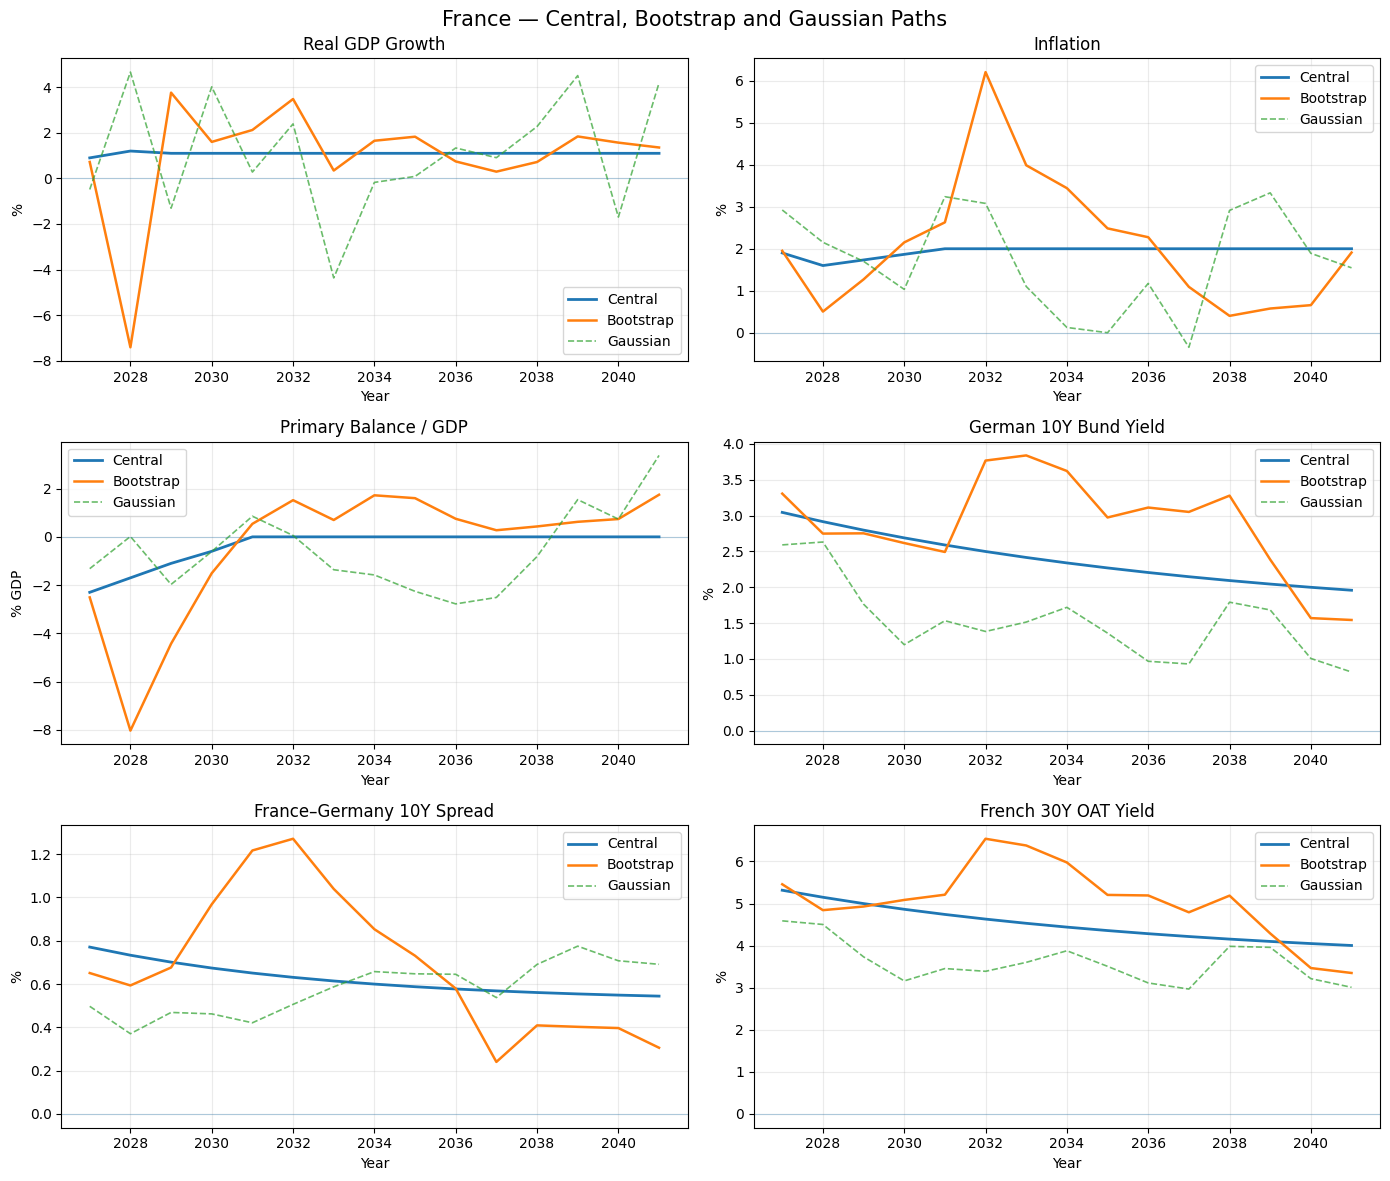

In [105]:
plot_specs = [
    {
        "column": "real_growth",
        "title": "Real GDP Growth",
        "ylabel": "%",
    },
    {
        "column": "inflation",
        "title": "Inflation",
        "ylabel": "%",
    },
    {
        "column": "primary_balance_gdp",
        "title": "Primary Balance / GDP",
        "ylabel": "% GDP",
    },
    {
        "column": "bund_10y",
        "title": "German 10Y Bund Yield",
        "ylabel": "%",
    },
    {
        "column": "france_spread_10y",
        "title": "France–Germany 10Y Spread",
        "ylabel": "%",
    },
    {
        "column": "oat_30y",
        "title": "French 30Y OAT Yield",
        "ylabel": "%",
    },
]


central_plot = (
    central_path[
        central_path[
            "year"
        ] >= 2027
    ]
    .copy()
)


fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 12),
)

axes = axes.flatten()


for ax, spec in zip(
    axes,
    plot_specs,
):

    column = (
        spec[
            "column"
        ]
    )

    ax.plot(
        central_plot[
            "year"
        ],
        central_plot[
            column
        ] * 100,
        label="Central",
        linewidth=2,
    )

    ax.plot(
        stochastic_path_bootstrap[
            "year"
        ],
        stochastic_path_bootstrap[
            column
        ] * 100,
        label="Bootstrap",
        linewidth=1.8,
    )

    ax.plot(
        stochastic_path_gaussian[
            "year"
        ],
        stochastic_path_gaussian[
            column
        ] * 100,
        label="Gaussian",
        linewidth=1.2,
        linestyle="--",
        alpha=0.7,
    )

    ax.axhline(
        0,
        linewidth=0.8,
        alpha=0.3,
    )

    ax.set_title(
        spec[
            "title"
        ]
    )

    ax.set_xlabel(
        "Year"
    )

    ax.set_ylabel(
        spec[
            "ylabel"
        ]
    )

    ax.grid(
        alpha=0.25
    )

    ax.legend()


fig.suptitle(
    "France — Central, Bootstrap and Gaussian Paths",
    fontsize=15,
)

plt.tight_layout()

plt.show()

In [106]:
stochastic_indexed = (
    stochastic_path
    .set_index(
        "year"
    )
)


stochastic_nominal_growth = (
    stochastic_indexed[
        "nominal_growth"
    ]
)


stochastic_primary_balance = (
    stochastic_indexed[
        "primary_balance_gdp"
    ]
)


stochastic_inflation = (
    stochastic_indexed[
        "inflation"
    ]
)

In [107]:
def build_stochastic_market_curves(
    stochastic_path,
):
    """
    Translate the stochastic French 30Y path into
    annual nominal and real yield curves.
    """

    result = {}

    for _, row in (
        stochastic_path.iterrows()
    ):

        year = int(
            row[
                "year"
            ]
        )

        oat_30y = float(
            row[
                "oat_30y"
            ]
        )

        # ----------------------------------------------------
        # Nominal OAT curve
        # ----------------------------------------------------

        nominal_curve = (
            curve_from_30y_anchor(
                oat_30y_yield=(
                    oat_30y
                ),
                offsets_to_30y=(
                    NOMINAL_CURVE_OFFSETS_TO_30Y
                ),
            )
        )

        # ----------------------------------------------------
        # First-pass real-curve transmission
        # ----------------------------------------------------

        yield_shift = (
            oat_30y
            -
            BASELINE_OAT_30Y
        )

        real_euro_curve = {
            maturity:
                rate
                + yield_shift

            for maturity, rate
            in baseline_real_euro_curve.items()
        }

        real_fr_curve = {
            maturity:
                rate
                + yield_shift

            for maturity, rate
            in baseline_real_fr_curve.items()
        }

        result[
            year
        ] = {
            "nominal":
                nominal_curve,

            "real_euro":
                real_euro_curve,

            "real_fr":
                real_fr_curve,
        }

    return result

In [108]:
stochastic_market_curves = (
    build_stochastic_market_curves(
        stochastic_path
    )
)

In [109]:
aft_stochastic_path, aft_stochastic_final = (
    simulate_portfolio_path(
        initial_portfolio=portfolio,

        initial_gdp_eur=(
            BASELINE[
                "initial_gdp_eur"
            ]
        ),

        start_year=(
            BASELINE[
                "start_year"
            ]
        ),

        years=(
            BASELINE[
                "horizon_years"
            ]
        ),

        nominal_growth=(
            stochastic_nominal_growth
            .to_dict()
        ),

        primary_balance_ratio=(
            stochastic_primary_balance
            .to_dict()
        ),

        market_curves=(
            stochastic_market_curves
        ),

        issuance_plan=(
            ISSUANCE_PLAN
        ),

        french_inflation=(
            stochastic_inflation
            .to_dict()
        ),

        euro_inflation=(
            stochastic_inflation
            .to_dict()
        ),
    )
)

In [110]:
stochastic_aft_cost_shock = pd.Series(
    (
        aft_stochastic_path[
            "total_financing_cost_eur"
        ].to_numpy()
        -
        aft_baseline_path[
            "total_financing_cost_eur"
        ].to_numpy()
    ),

    index=YEARS,
)

In [111]:
gg_stochastic_path = (
    simulate_general_government_dsa(
        years=YEARS,

        initial_gdp_eur=(
            BASELINE[
                "initial_gdp_eur"
            ]
        ),

        initial_debt_gdp=(
            BASELINE[
                "initial_debt_gdp"
            ]
        ),

        baseline_effective_rate=(
            BASELINE[
                "effective_interest_rate"
            ]
        ),

        nominal_growth=(
            stochastic_nominal_growth
        ),

        primary_balance_gdp=(
            stochastic_primary_balance
        ),

        interest_cost_shock=(
            stochastic_aft_cost_shock
        ),
    )
)

In [112]:
from sklearn.covariance import MinCovDet

In [ ]:
# ============================================================
# Robust covariance estimation
# ============================================================

X = residual_data[
    CALIBRATION_VARIABLES
].to_numpy(
    dtype=float
)


mcd = MinCovDet(
    random_state=RANDOM_SEED
).fit(
    X
)


ROBUST_RESIDUAL_MEAN = (
    mcd.location_
)


ROBUST_COVARIANCE_MATRIX = (
    mcd.covariance_
)